# Effective error generator の $\bar n$・ノイズレート依存

4種類の散逸ノイズを1種類ずつ倍率 $0, 0.5, 1, 2, 4$ に振り、他の3種類をnominal値に固定する。各 $\bar n$ でmaster equationを解き、QPTからerror channelを再構成した後、

$$\mathcal L_{\mathrm{eff}} = \log \mathcal E_{\mathrm{err}}$$

をPauli Hamiltonian項と対角Pauli散逸項に分解する。全15個の $h_P$ と $\gamma_P$ を保存し、weight 1をlocal、weight 2をcorrelated Pauli modeとして順位付けする。

> **解釈上の注意**：ここでのcorrelated modeは二体Pauli散逸モードであり、ノイズ源同士の統計的相関や相関浴を仮定・同定したものではない。

In [15]:
from pathlib import Path
import importlib
import os

# QPT worker内のBLAS/OpenMP多重並列を避ける。
for name in (
    'OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS',
):
    os.environ[name] = '1'
os.environ.setdefault('MPLCONFIGDIR', '/tmp/ms_gate_mpl')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

import error_generator_rate_nbar as egrn
egrn = importlib.reload(egrn)


## 1. 計算条件

既存のnoise-rate sweepと同じ物理パラメータを使う。倍率1の条件は4軸で共通なので、20表示条件を17個の一意なQPT条件へ自動的に縮約する。

In [16]:
NBAR_VALUES = (0.01, 1.0, 2.0, 3.0, 4.0)
RATE_MULTIPLIERS = (0.0, 0.5, 1.0, 2.0, 4.0)
OUTPUT_DIR = Path('results/error_generator_rate_nbar')
EXECUTE_QPT = True   # Falseならキャッシュの読出しだけ。
RESUME = True        # 完了したcondition/nbar点を再利用する。
WORKERS = min(32, os.cpu_count() or 1)

BASE_PARAMETERS = {
    'A': 0.125,
    'delta': 0.5,
    'rho0': 0.0,
    'n_bar_list': list(NBAR_VALUES),
    'time_points': 500,
    't_gate_phys': 100e-6,
    'heating_rate_phys': 10.0,
    'dephasing_rate_phys': 18.0,
    'T2_star': 0.3,
    'rayleigh_rate_phys': 3.0,
    'raman_rate_phys': 1.0,
    'eta': 0.1,
    'laser_intensity_fluctuation': 0.0,
    'laser_detuning_fluctuation': 0.0,
    'laser_rotation_angle_fluctuation': 0.0,
    'laser_noise_samples': 1,
    'laser_noise_seed': 1234,
    'use_full_order': True,
    'show_progress': True,
    'parallel_workers': WORKERS,
}

plan = egrn.build_single_axis_rate_plan(BASE_PARAMETERS, RATE_MULTIPLIERS)
print(f'QPT workers: {WORKERS}')
print(f"Displayed sweep conditions: {len(plan['requests'])}")
print(f"Unique physical conditions: {len(plan['catalog'])}")
display(plan['requests'])


QPT workers: 8
Displayed sweep conditions: 20
Unique physical conditions: 17


,noise_source,noise_title,multiplier,varied_strength_s^-1,condition_id,motional_heating_s^-1,motional_dephasing_s^-1,spin_dephasing_s^-1,photon_scattering_s^-1
0,motional_dephasing,Motional dephasing,0.0,0.000000,rates_d9ef54501046f3fe,10.0,0.0,3.333333,4.0
1,motional_dephasing,Motional dephasing,0.5,9.000000,rates_5f6c6c21f7229406,10.0,9.0,3.333333,4.0
2,motional_dephasing,Motional dephasing,1.0,18.000000,rates_5052894f24b711d8,10.0,18.0,3.333333,4.0
3,motional_dephasing,Motional dephasing,2.0,36.000000,rates_270dbb0a181563d6,10.0,36.0,3.333333,4.0
4,motional_dephasing,Motional dephasing,4.0,72.000000,rates_4f154ffd26e66cb6,10.0,72.0,3.333333,4.0
5,motional_heating,Motional heating,0.0,0.000000,rates_955f664628d0ac20,0.0,18.0,3.333333,4.0
6,motional_heating,Motional heating,0.5,5.000000,rates_85cf44b10a0a8ca1,5.0,18.0,3.333333,4.0
7,motional_heating,Motional heating,1.0,10.000000,rates_5052894f24b711d8,10.0,18.0,3.333333,4.0
8,motional_heating,Motional heating,2.0,20.000000,rates_b9547fee09e3ad72,20.0,18.0,3.333333,4.0
9,motional_heating,Motional heating,4.0,40.000000,rates_c0f0c540e1976c9c,40.0,18.0,3.333333,4.0


## 2. Error-channel QPT

各condition/$\bar n$点を独立したNPZとして保存する。中断後に再実行すると、未計算点だけをmaster equationから再計算する。

In [17]:
sweep = egrn.run_or_load_qpt_sweep(
    output_dir=OUTPUT_DIR,
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    rate_multipliers=RATE_MULTIPLIERS,
    convention='undo_before_actual',
    execute=EXECUTE_QPT,
    resume=RESUME,
)
print(
    f"Cached points: {sweep['completed_point_count']}/"
    f"{sweep['total_point_count']}; complete={sweep['complete']}"
)
print(
    f"Pending ME evolutions: "
    f"{sweep['pending_master_equation_evolutions']}"
)
if not sweep['pending'].empty:
    display(sweep['pending'])


Cached points: 85/85; complete=True
Pending ME evolutions: 0


## 3. $\bar n$・ノイズレート依存：effective error generator

trace-normalized $\chi$ をCPTP集合へ射影し、PTMの行列対数を取る。Hamiltonian部分は全15個のPauli commutatorへ最小二乗フィットし、散逸部分は全15個の対角Pauli dissipatorへ非負最小二乗フィットする。

この節で保存する主な量は、単純なaverage infidelity、全 $h_P$、全 $\gamma_P$、および各点のdominant local/correlated modeである。

In [18]:
if not sweep['complete']:
    raise RuntimeError(
        'QPT cache is incomplete. Set EXECUTE_QPT=True and rerun Section 2.'
    )

generators = egrn.extract_cached_generators(sweep)
summary = generators['summary']
coefficients = generators['coefficients']
print(f'Generator summary rows: {len(summary)}')
print(f'Pauli coefficient rows: {len(coefficients)}')
display(summary.head())


Extract generator 1/85: rates_044a6c959026d60d, nbar=0.01
Extract generator 2/85: rates_044a6c959026d60d, nbar=1
Extract generator 3/85: rates_044a6c959026d60d, nbar=2
Extract generator 4/85: rates_044a6c959026d60d, nbar=3
Extract generator 5/85: rates_044a6c959026d60d, nbar=4
Extract generator 6/85: rates_270dbb0a181563d6, nbar=0.01
Extract generator 7/85: rates_270dbb0a181563d6, nbar=1
Extract generator 8/85: rates_270dbb0a181563d6, nbar=2
Extract generator 9/85: rates_270dbb0a181563d6, nbar=3
Extract generator 10/85: rates_270dbb0a181563d6, nbar=4
Extract generator 11/85: rates_2bd2b1433a45a59b, nbar=0.01
Extract generator 12/85: rates_2bd2b1433a45a59b, nbar=1
Extract generator 13/85: rates_2bd2b1433a45a59b, nbar=2
Extract generator 14/85: rates_2bd2b1433a45a59b, nbar=3
Extract generator 15/85: rates_2bd2b1433a45a59b, nbar=4
Extract generator 16/85: rates_4f154ffd26e66cb6, nbar=0.01
Extract generator 17/85: rates_4f154ffd26e66cb6, nbar=1
Extract generator 18/85: rates_4f154ffd26e66c

,noise_source,noise_title,multiplier,varied_strength_s^-1,condition_id,nbar,motional_heating_s^-1,motional_dephasing_s^-1,spin_dephasing_s^-1,photon_scattering_s^-1,...,hamiltonian_fit_frobenius_norm,pauli_dissipator_fit_frobenius_norm,unmodeled_generator_frobenius_norm,generator_reconstruction_error,generator_imaginary_frobenius_norm,gamma_nnls_residual,cptp_projection_iterations,cptp_min_choi_eigenvalue,cptp_tp_frobenius_error,cptp_relative_final_step
0,motional_dephasing,Motional dephasing,0.0,0.0,rates_d9ef54501046f3fe,0.01,10.0,0.0,3.333333,4.0,...,0.077751,0.006996,0.002498,4.690544e-15,3.150837e-15,0.002498,1.0,1.152346e-07,1.110272e-16,4.425164e-16
1,motional_dephasing,Motional dephasing,0.0,0.0,rates_d9ef54501046f3fe,1.00,10.0,0.0,3.333333,4.0,...,0.163184,0.009836,0.003316,6.572055e-15,2.690786e-15,0.003316,1.0,1.636115e-07,1.112024e-16,5.058675e-16
2,motional_dephasing,Motional dephasing,0.0,0.0,rates_d9ef54501046f3fe,2.00,10.0,0.0,3.333333,4.0,...,0.247956,0.014890,0.004070,5.223365e-15,1.979655e-15,0.004070,1.0,1.899066e-07,1.583462e-16,1.485411e-15
3,motional_dephasing,Motional dephasing,0.0,0.0,rates_d9ef54501046f3fe,3.00,10.0,0.0,3.333333,4.0,...,0.331141,0.022086,0.004734,4.920571e-15,1.740485e-15,0.004734,5.0,-2.139630e-12,2.055714e-17,4.734196e-12
4,motional_dephasing,Motional dephasing,0.0,0.0,rates_d9ef54501046f3fe,4.00,10.0,0.0,3.333333,4.0,...,0.412675,0.031228,0.005335,5.682047e-15,2.313148e-15,0.005335,5.0,-1.375495e-12,2.266531e-16,2.603636e-12


### 3.1 Dominant local / correlated Pauli散逸モード

各点でweight 1（local）とweight 2（correlated）を別々に順位付けする。下表は各クラス上位3モードの生の $\gamma_P$ であり、Pearson相関など別の統計量は導入しない。

In [19]:
outputs = egrn.save_analysis_outputs(generators, OUTPUT_DIR)
ranked = outputs['ranked']

max_nbar = max(NBAR_VALUES)
max_rate = max(RATE_MULTIPLIERS)
extreme = summary[
    np.isclose(summary['nbar'], max_nbar)
    & np.isclose(summary['multiplier'], max_rate)
][[
    'noise_source', 'nbar', 'multiplier', 'average_infidelity',
    'dominant_local_pauli', 'dominant_local_gamma_per_gate',
    'dominant_correlated_pauli', 'dominant_correlated_gamma_per_gate',
    'gamma_XX_per_gate', 'unmodeled_generator_frobenius_norm',
]]
print('Highest tested nbar and rate multiplier')
display(extreme)

print('Top-3 modes at the same four endpoint conditions')
display(ranked[
    np.isclose(ranked['nbar'], max_nbar)
    & np.isclose(ranked['multiplier'], max_rate)
][[
    'noise_source', 'mode_class', 'rank_within_class',
    'pauli', 'gamma_per_gate',
]])


Highest tested nbar and rate multiplier


,noise_source,nbar,multiplier,average_infidelity,dominant_local_pauli,dominant_local_gamma_per_gate,dominant_correlated_pauli,dominant_correlated_gamma_per_gate,gamma_XX_per_gate,unmodeled_generator_frobenius_norm
24,motional_dephasing,4.0,4.0,0.020626,XI,0.007688,XX,0.004784,0.004784,0.061307
49,motional_heating,4.0,4.0,0.013344,IX,0.003154,XX,0.004296,0.004296,0.025041
74,photon_scattering,4.0,4.0,0.013932,XI,0.002551,XX,0.004293,0.004293,0.019713
99,spin_dephasing,4.0,4.0,0.013068,IX,0.002476,XX,0.004293,0.004293,0.019657


Top-3 modes at the same four endpoint conditions


,noise_source,mode_class,rank_within_class,pauli,gamma_per_gate
144,motional_dephasing,correlated,1,XX,0.004784
145,motional_dephasing,correlated,2,YX,0.000139
146,motional_dephasing,correlated,3,XY,0.000139
147,motional_dephasing,local,1,XI,0.007688
148,motional_dephasing,local,2,IX,0.007688
149,motional_dephasing,local,3,IZ,0.000139
294,motional_heating,correlated,1,XX,0.004296
295,motional_heating,correlated,2,YX,0.000139
296,motional_heating,correlated,3,XY,0.000139
297,motional_heating,local,1,IX,0.003154


### 3.2 レート増加に伴う変化

最初の図は $XX$ correlated dissipatorの $\bar n$・レート依存である。続く4枚は9個の二体Pauliモードを個別に示す。同じカラースケールを各ノイズ軸内で共有するため、どの二体モードが大きいかを直接比較できる。

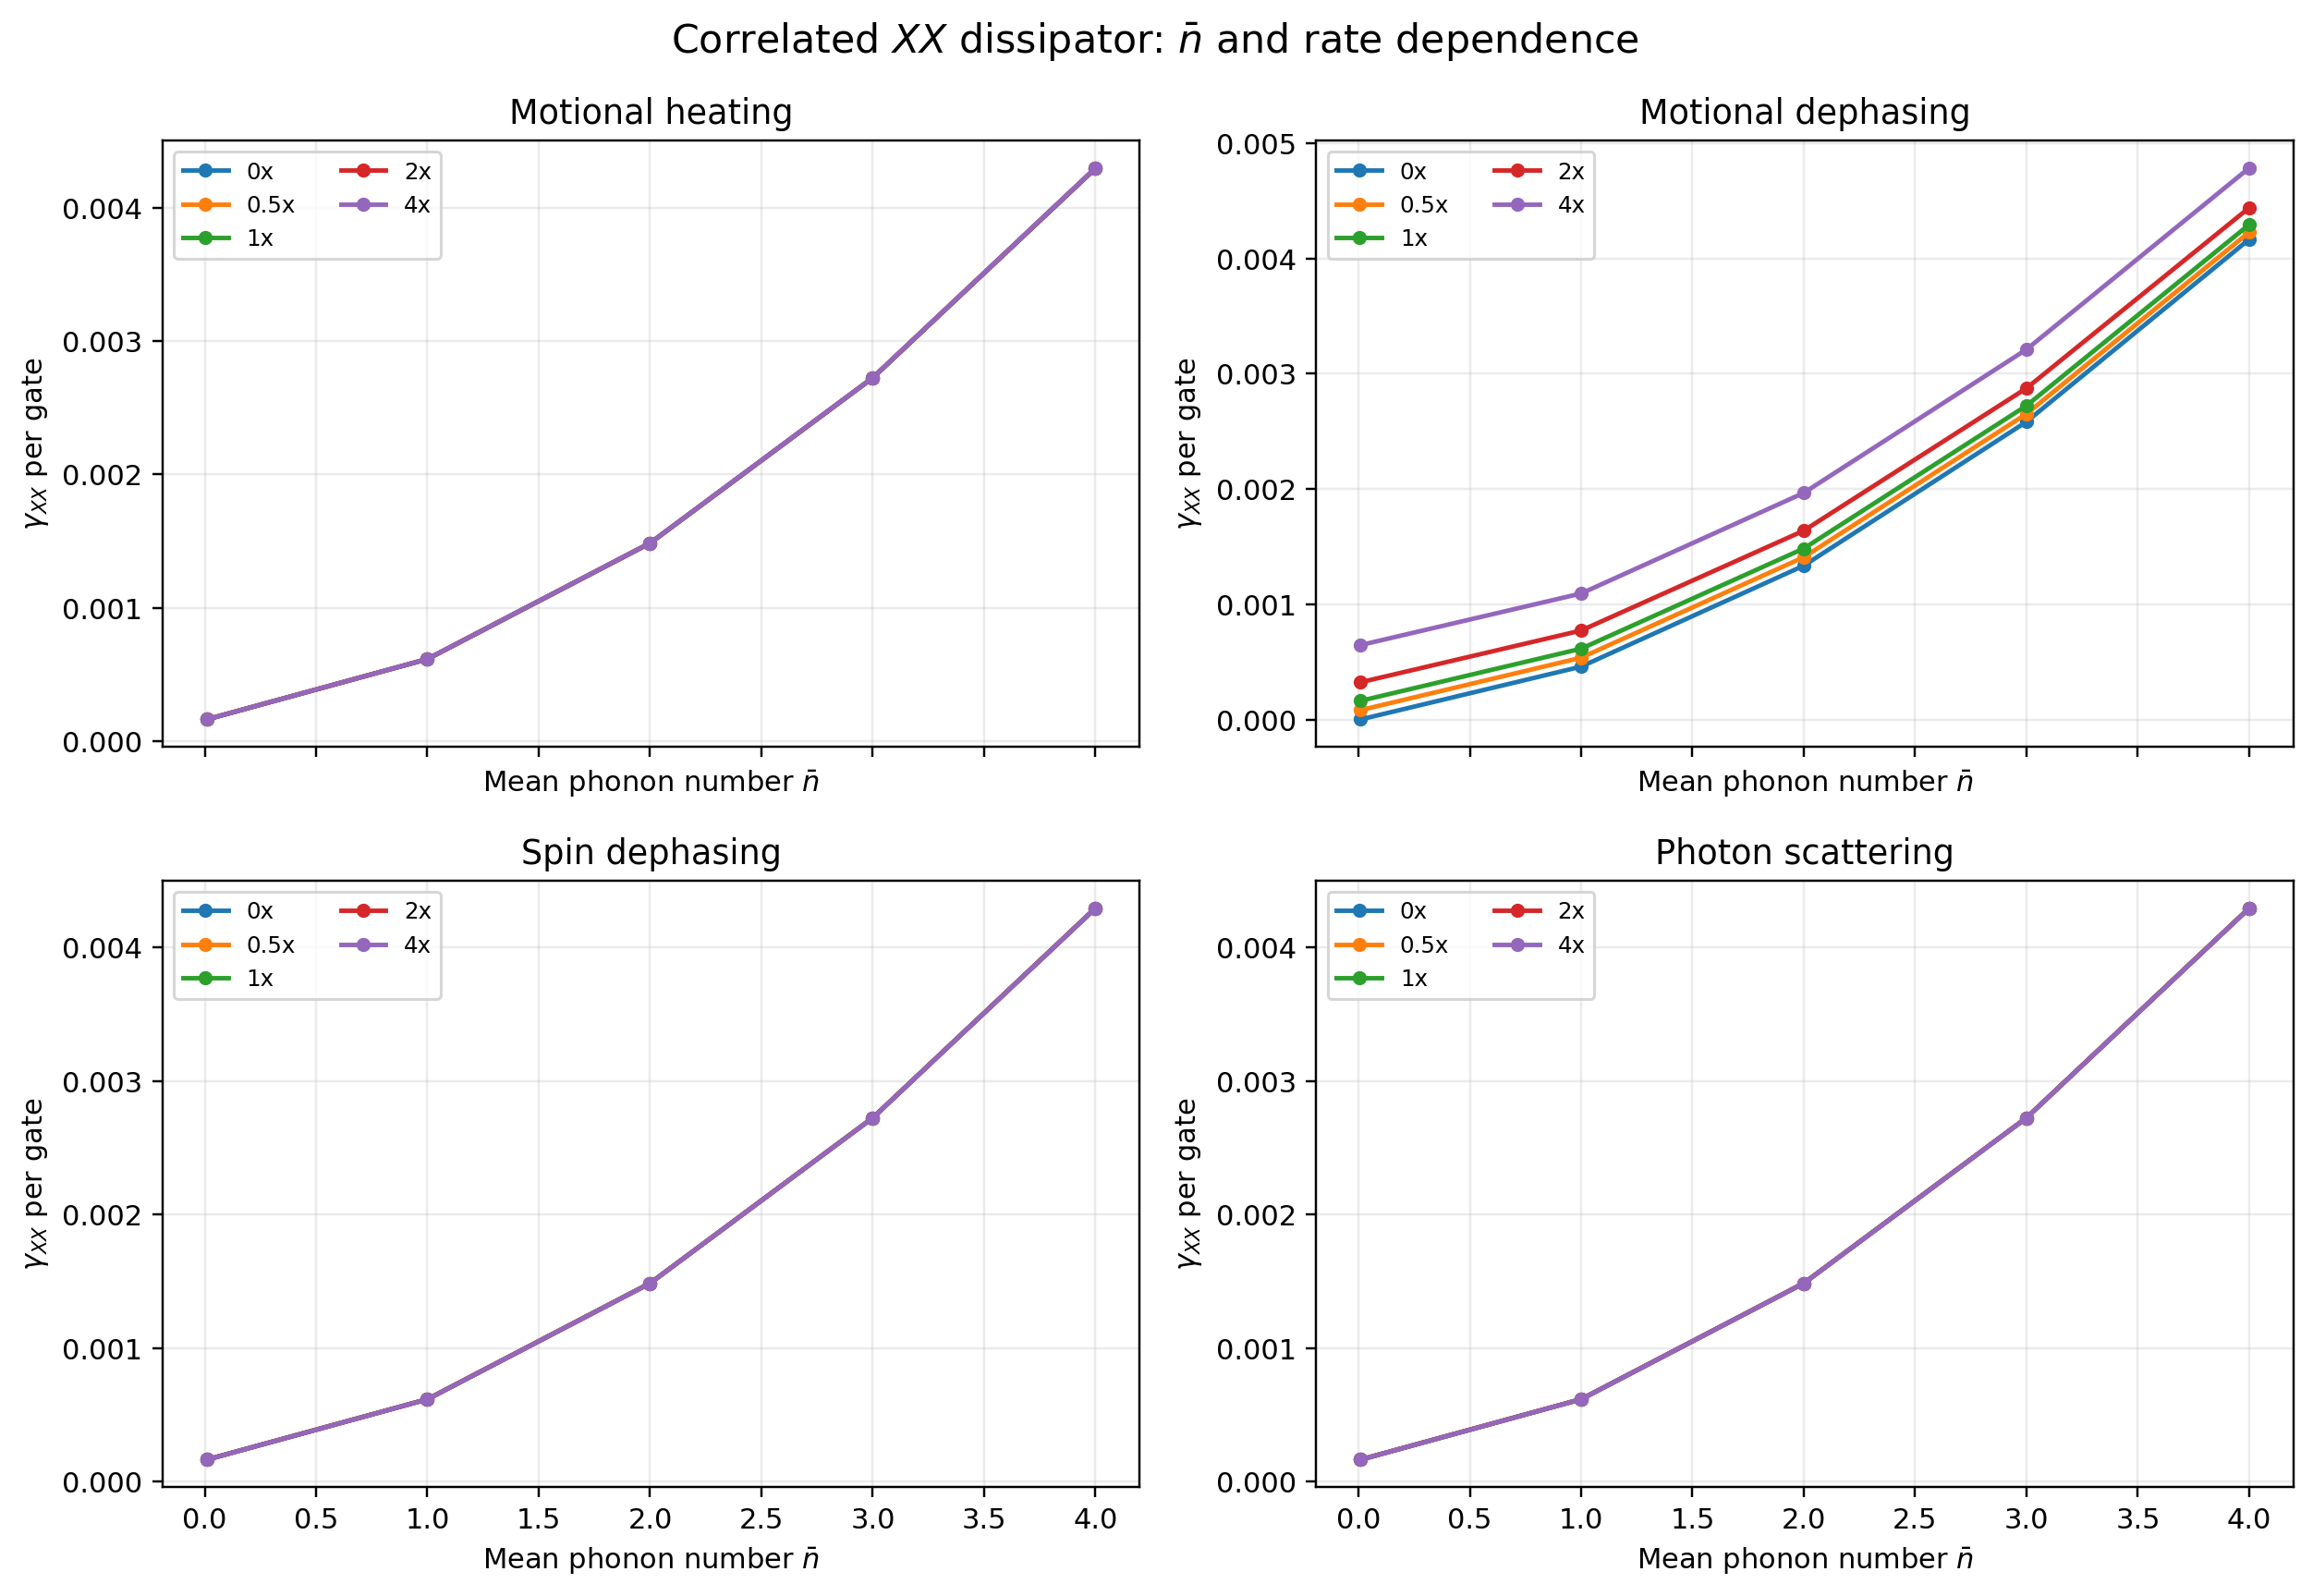

Motional heating


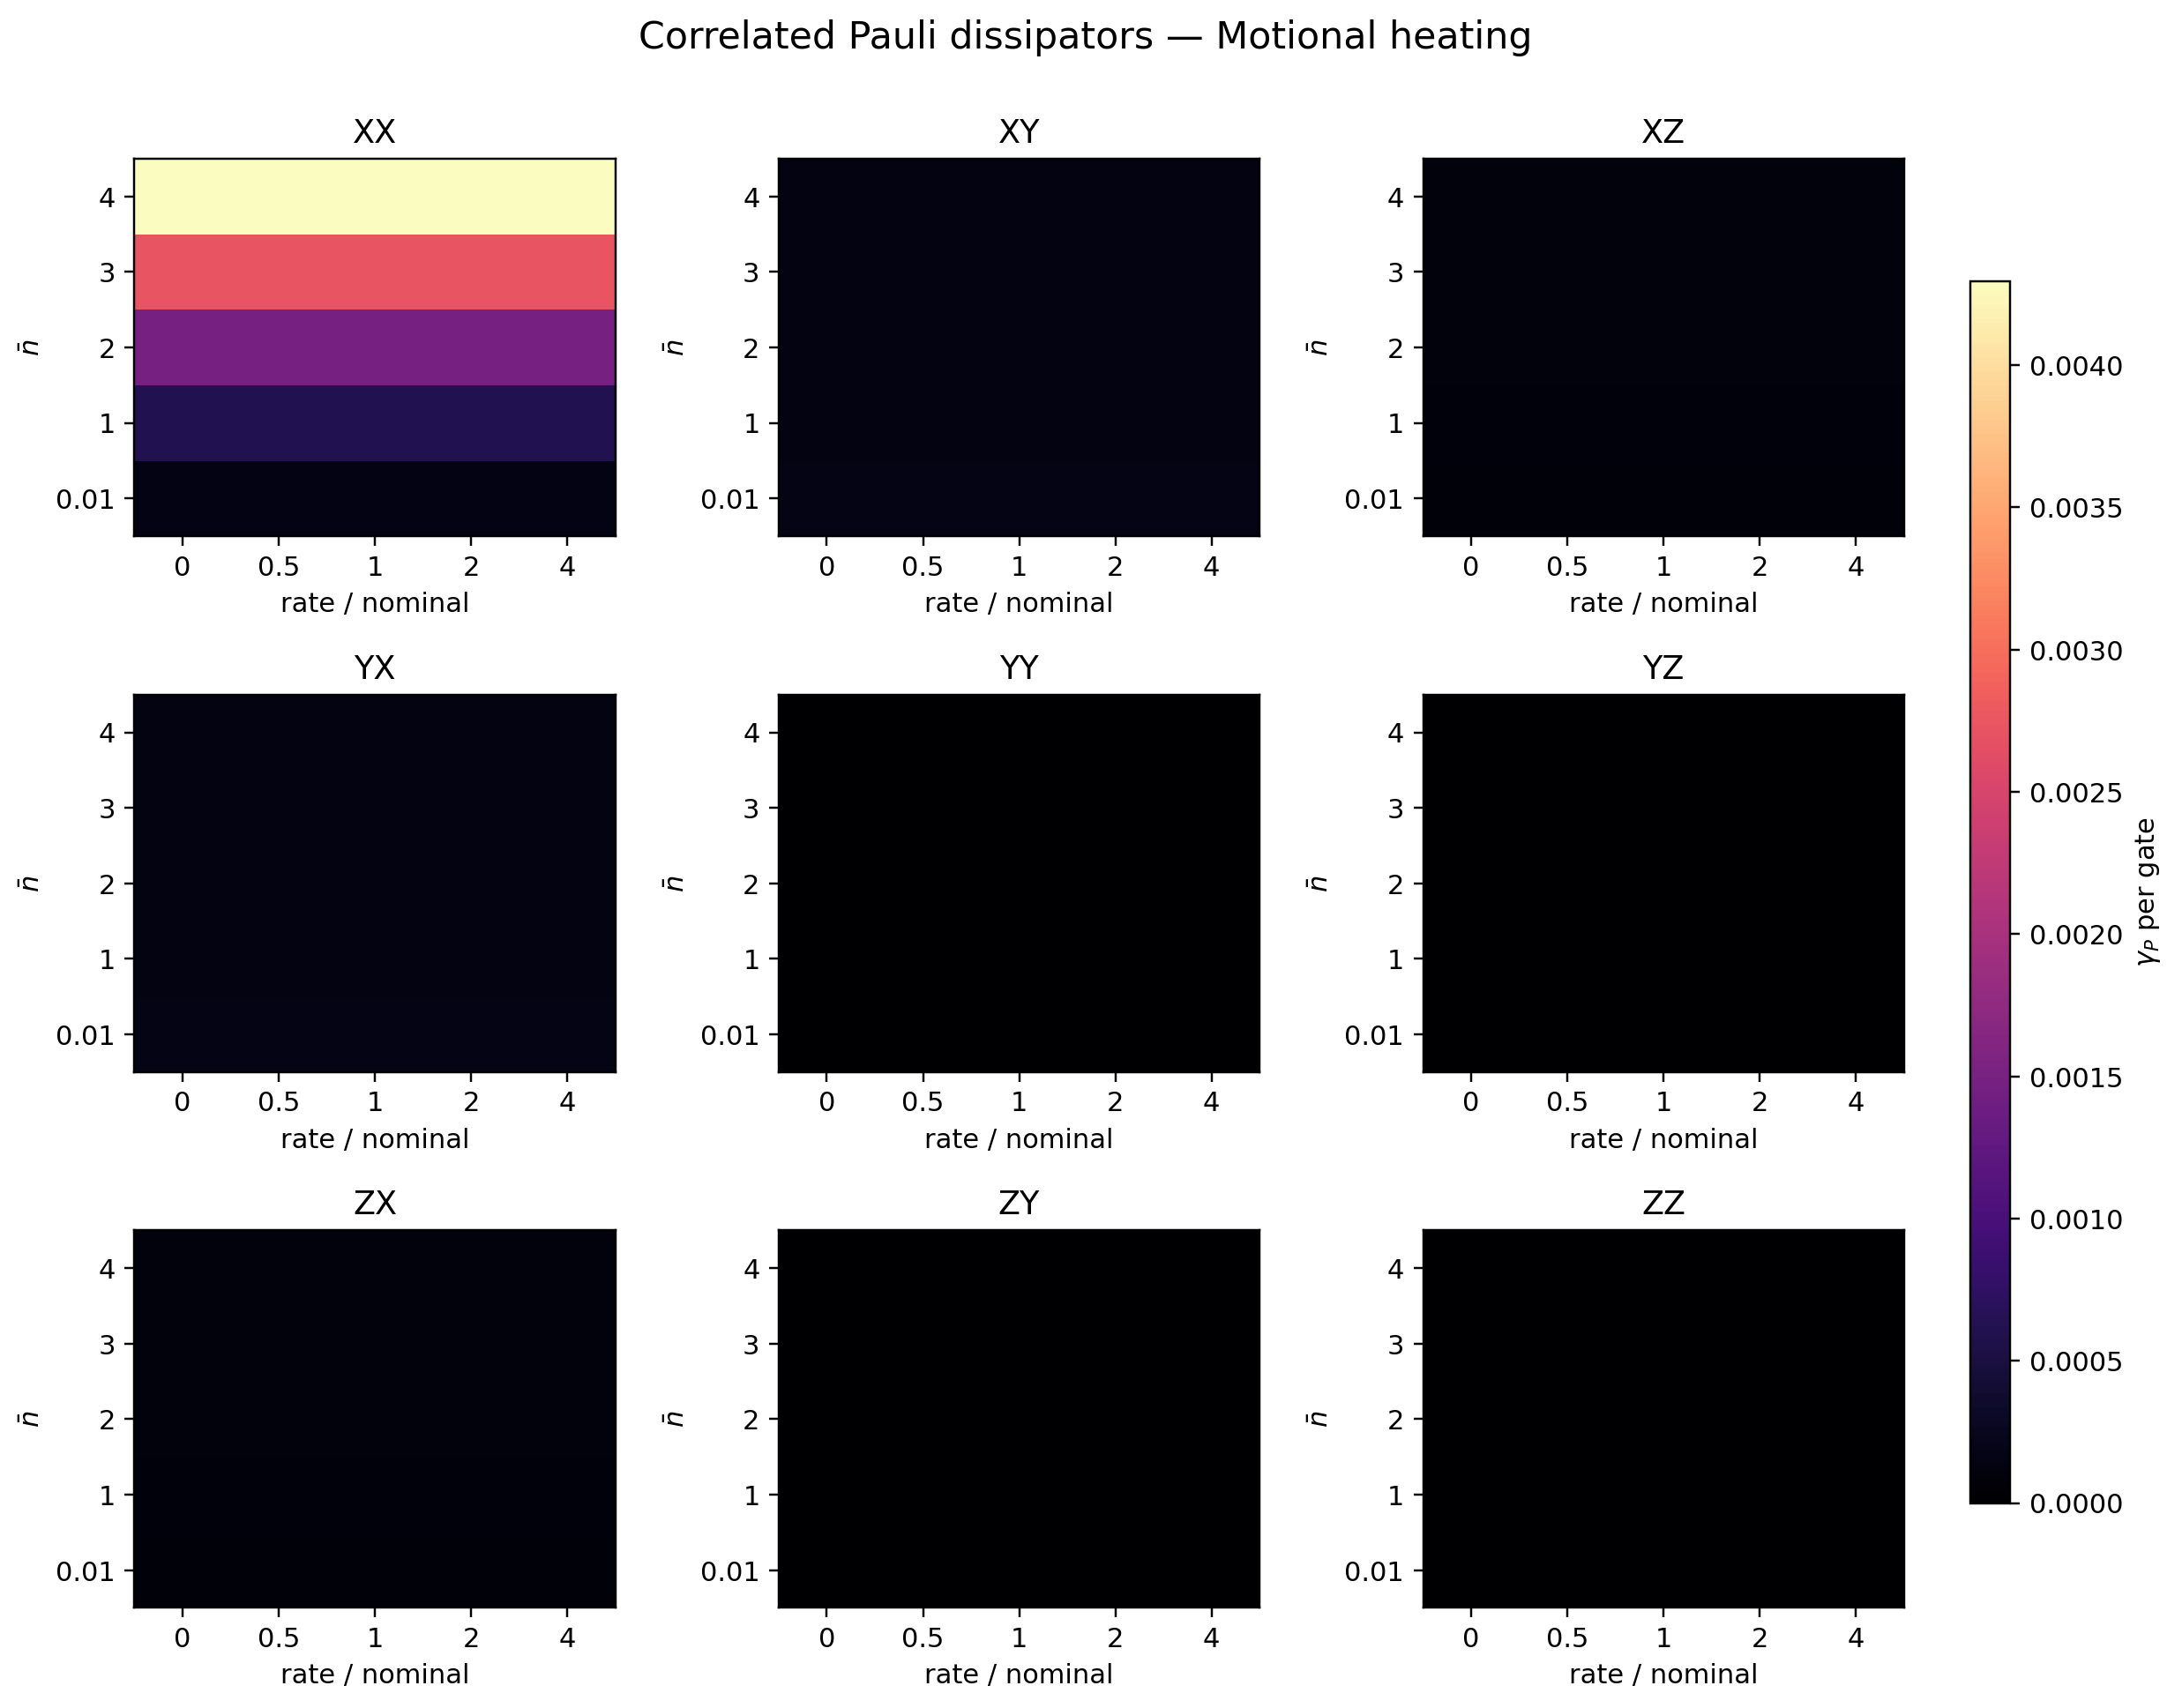

Motional dephasing


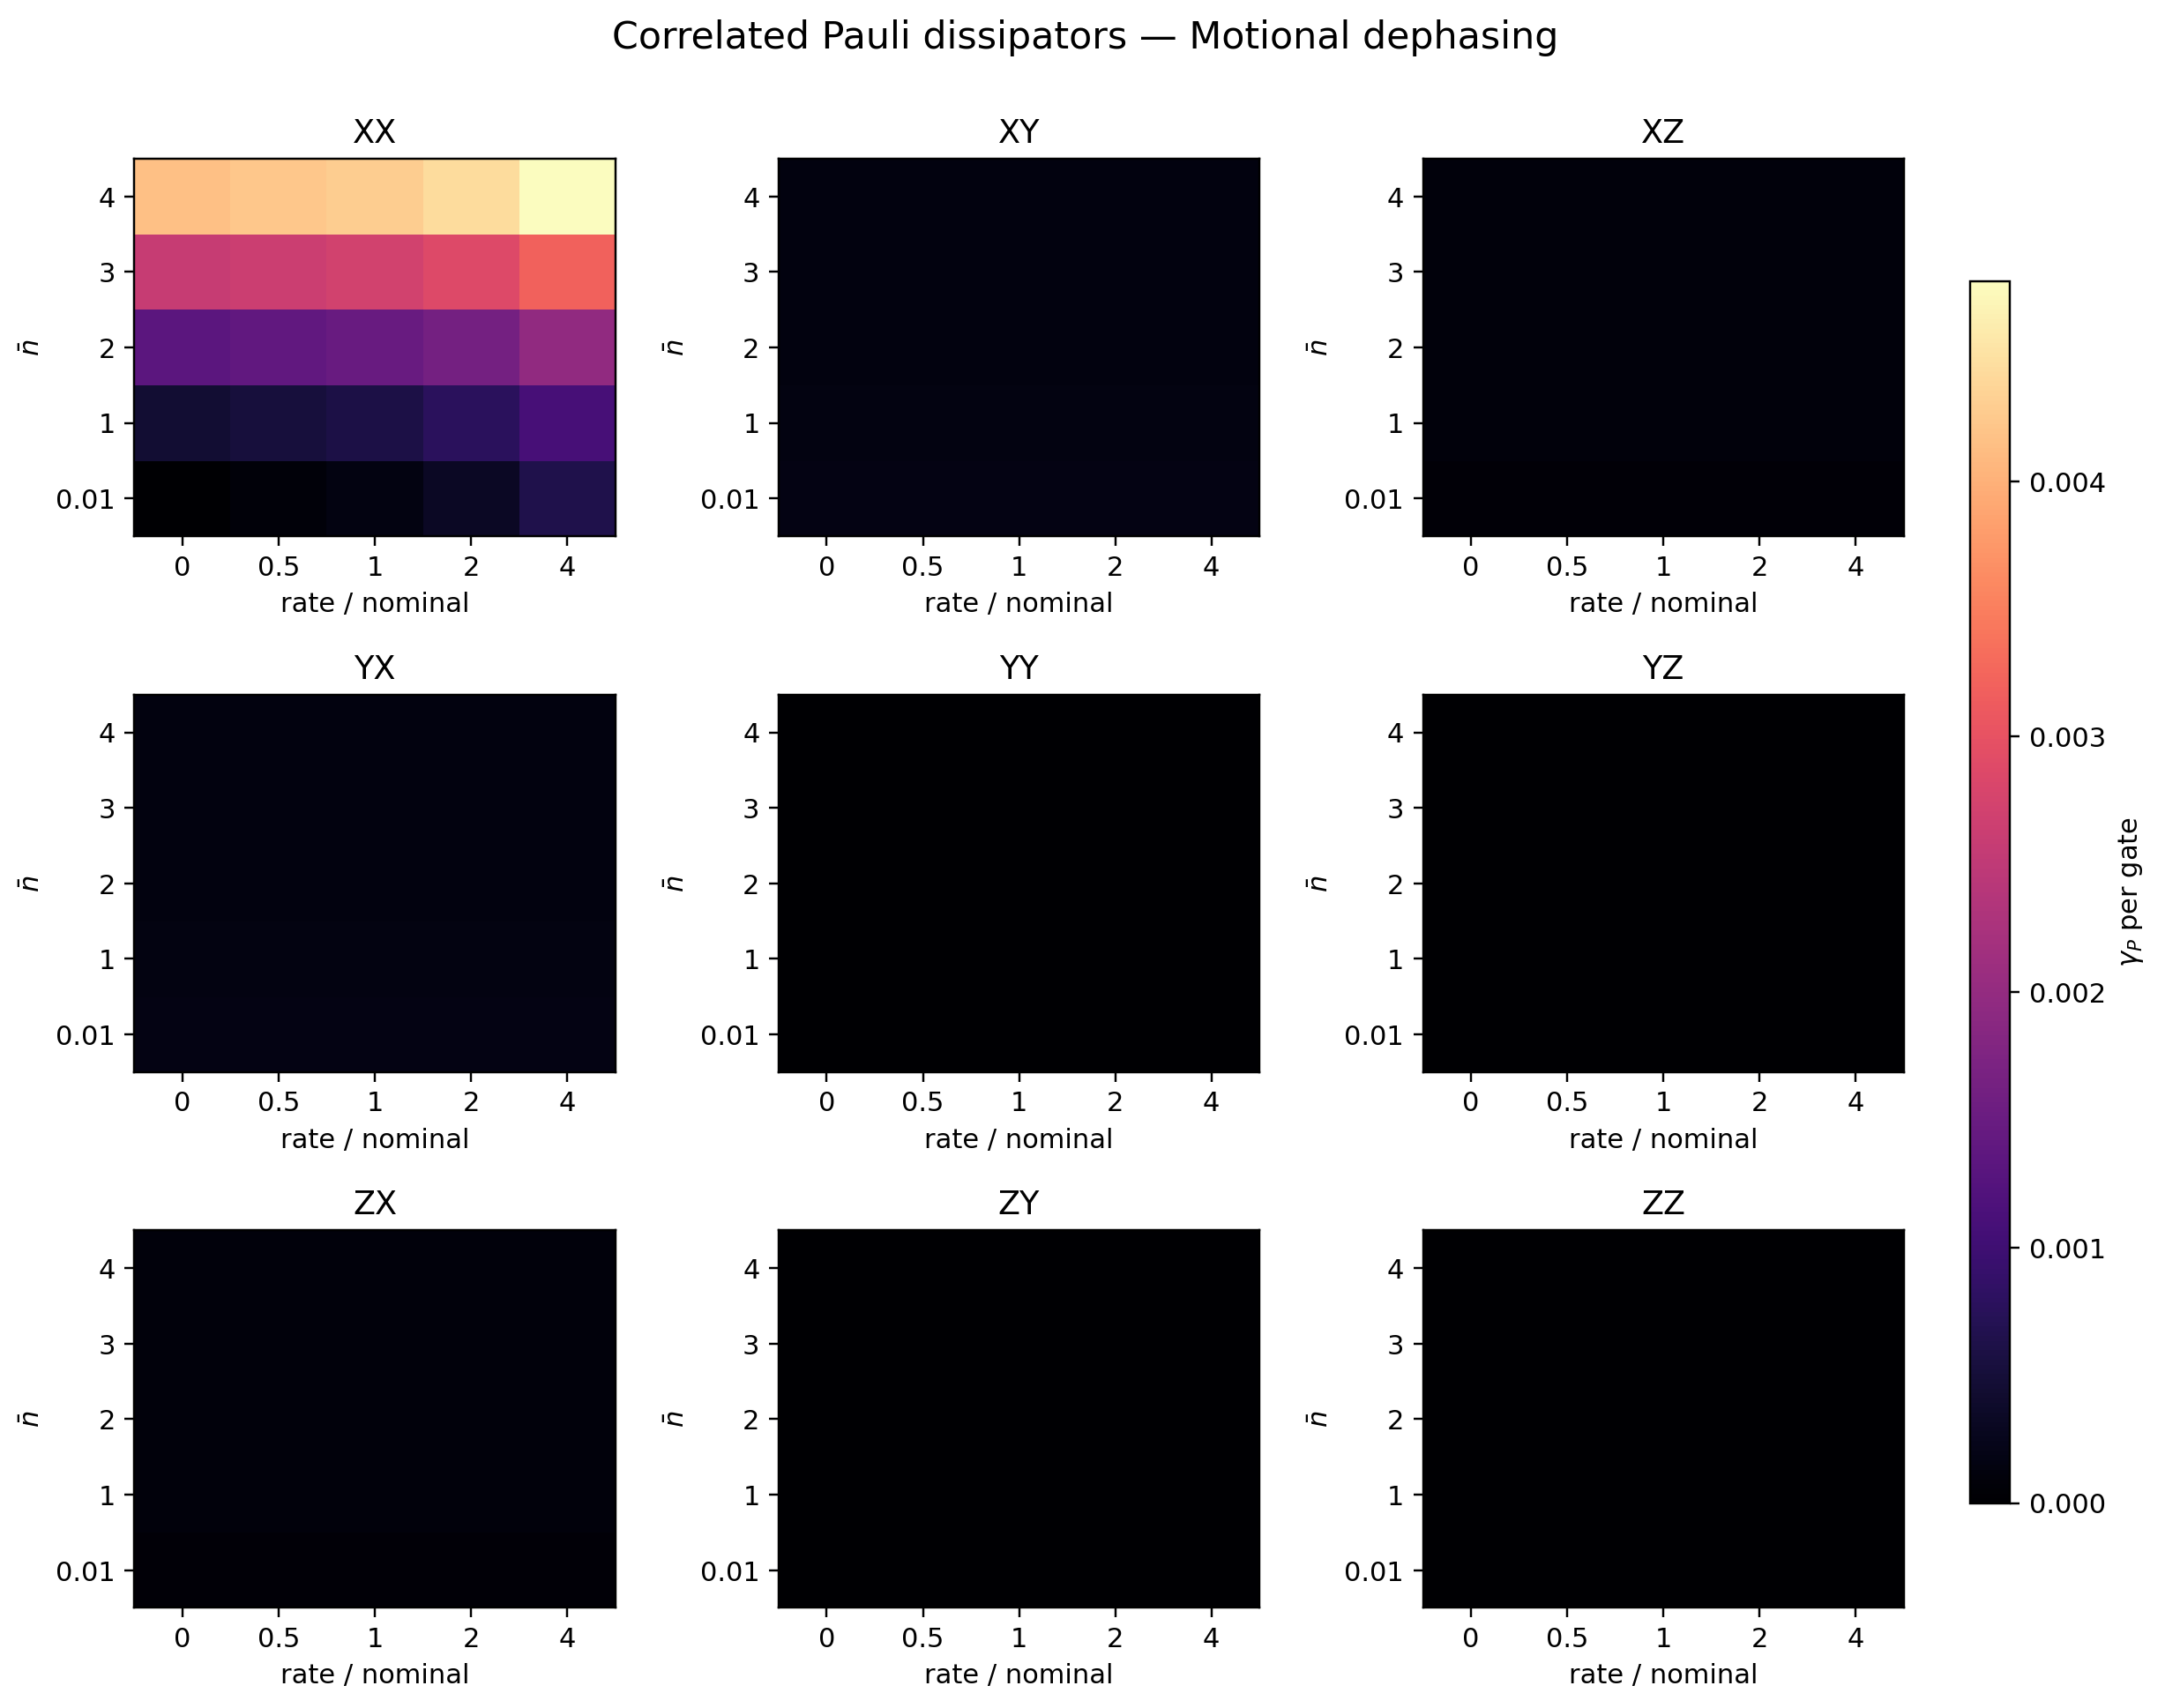

Spin dephasing


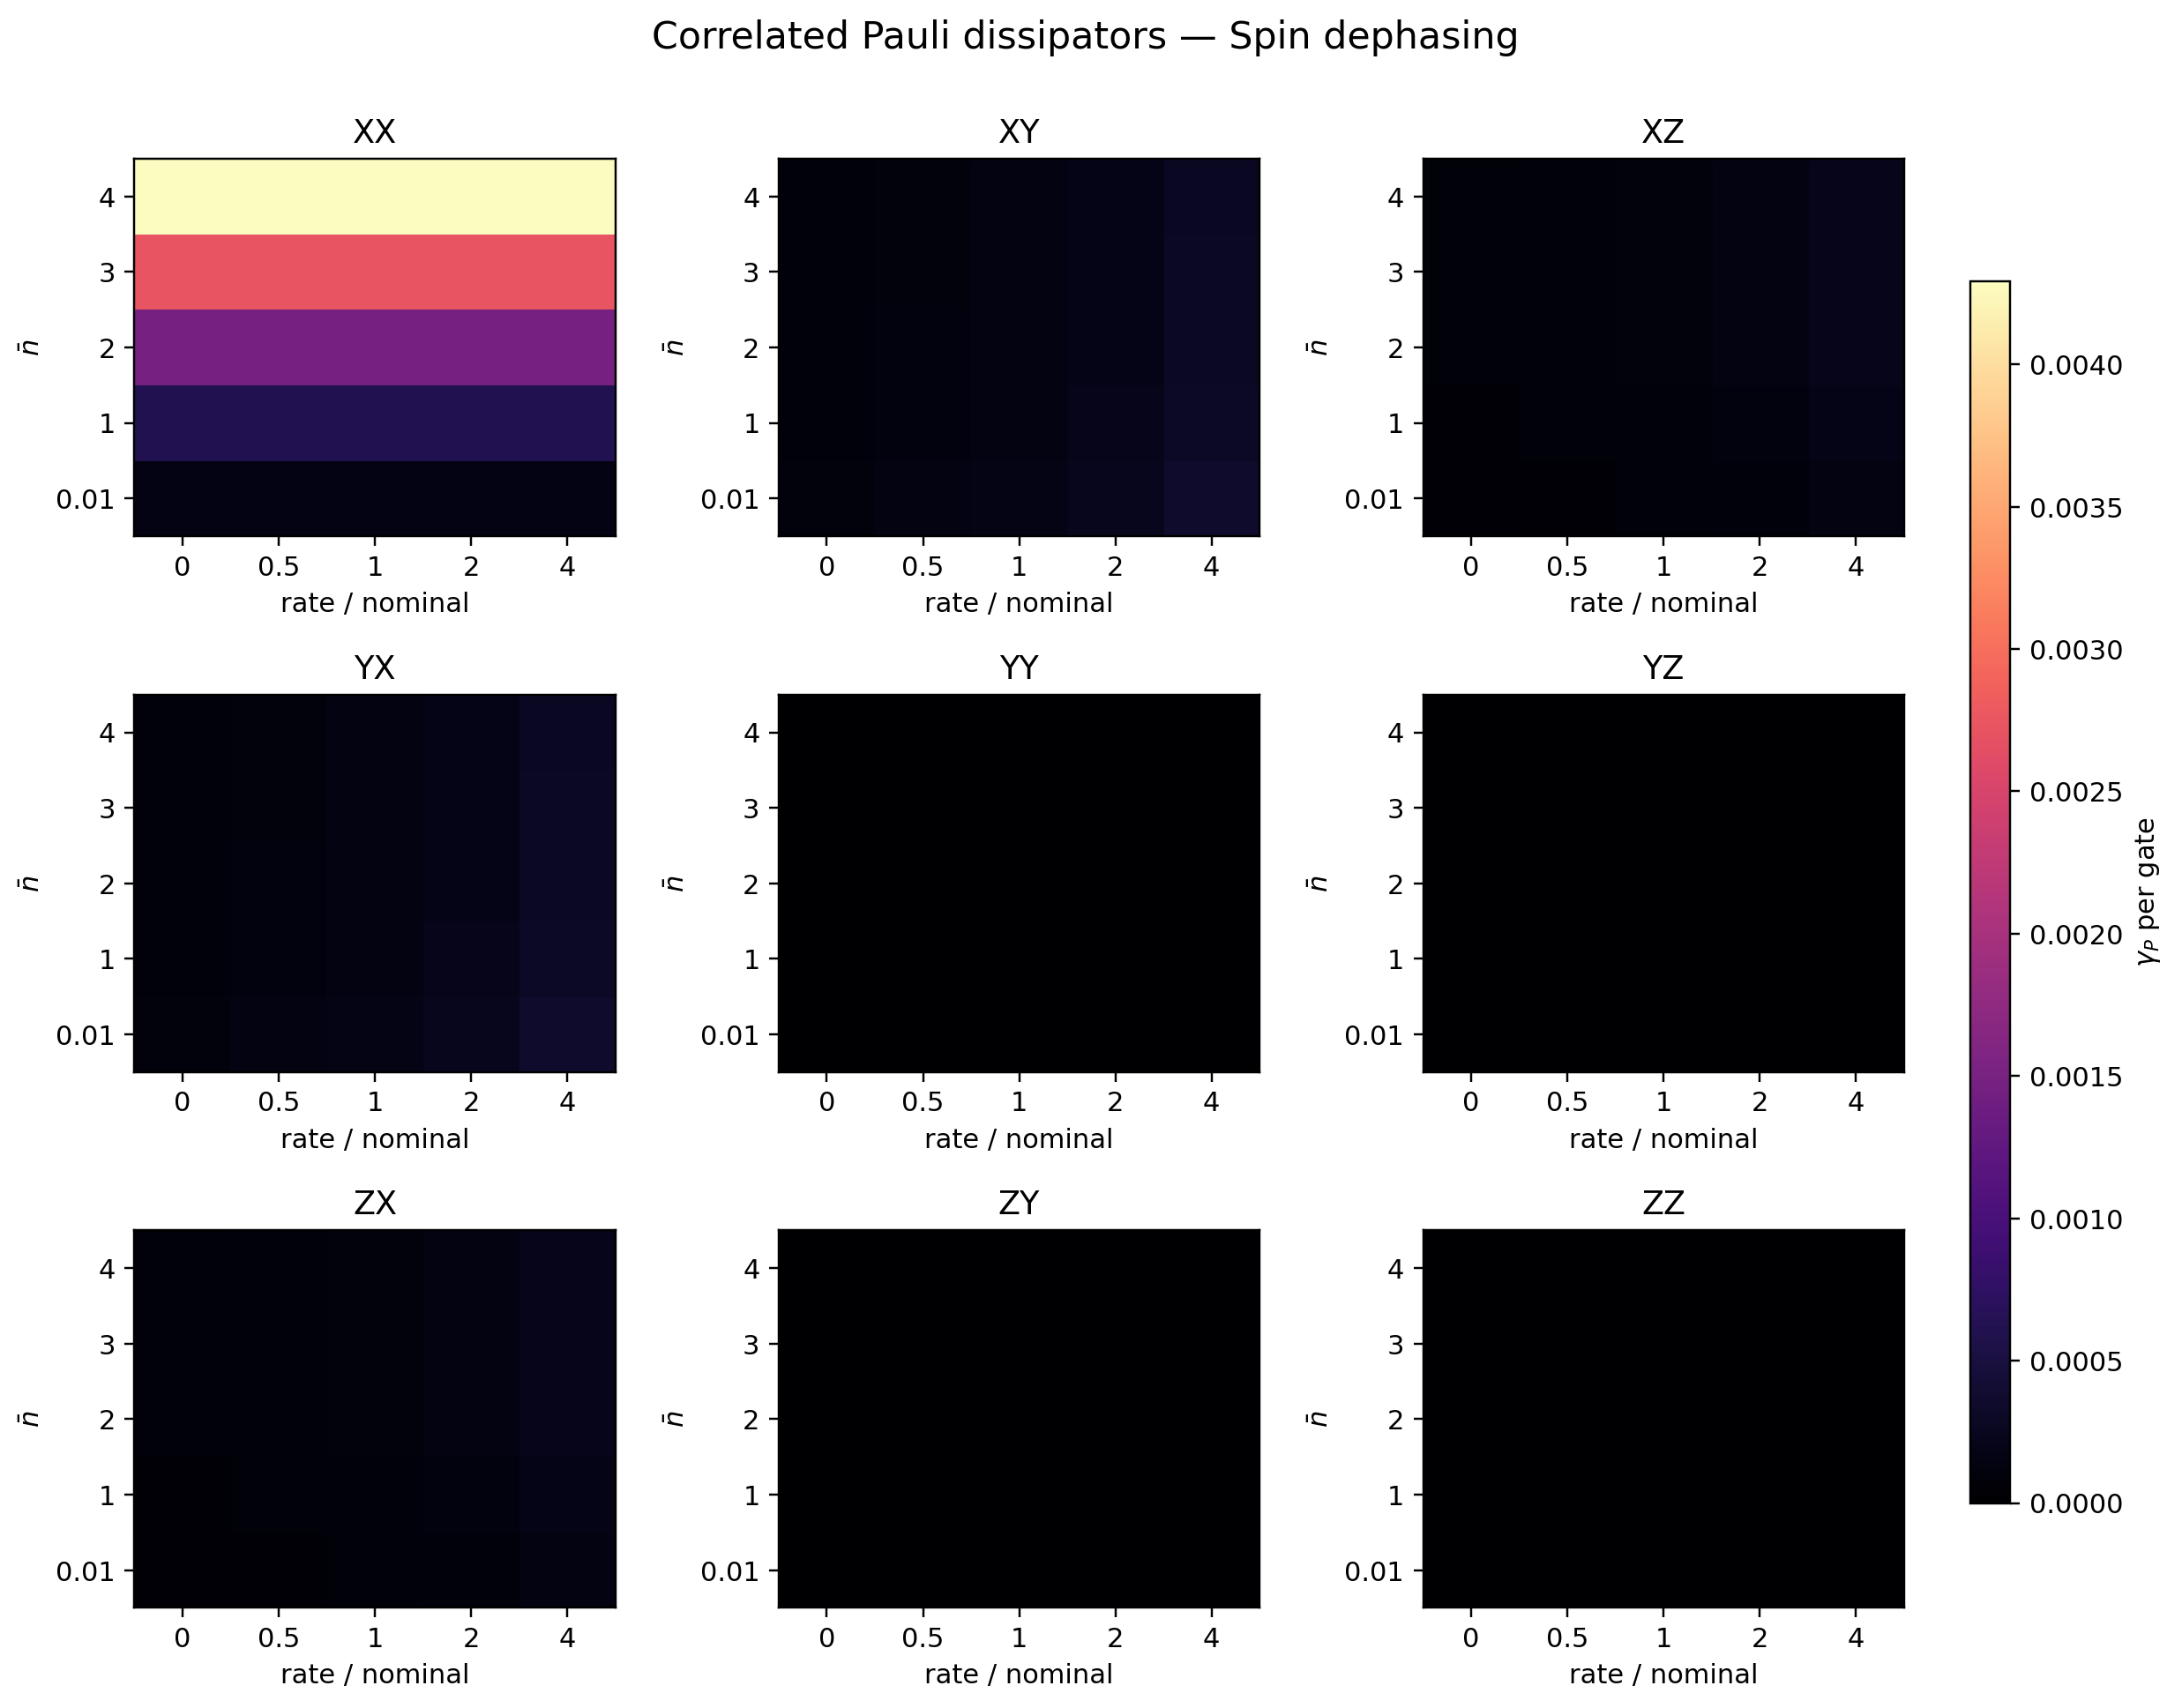

Photon scattering


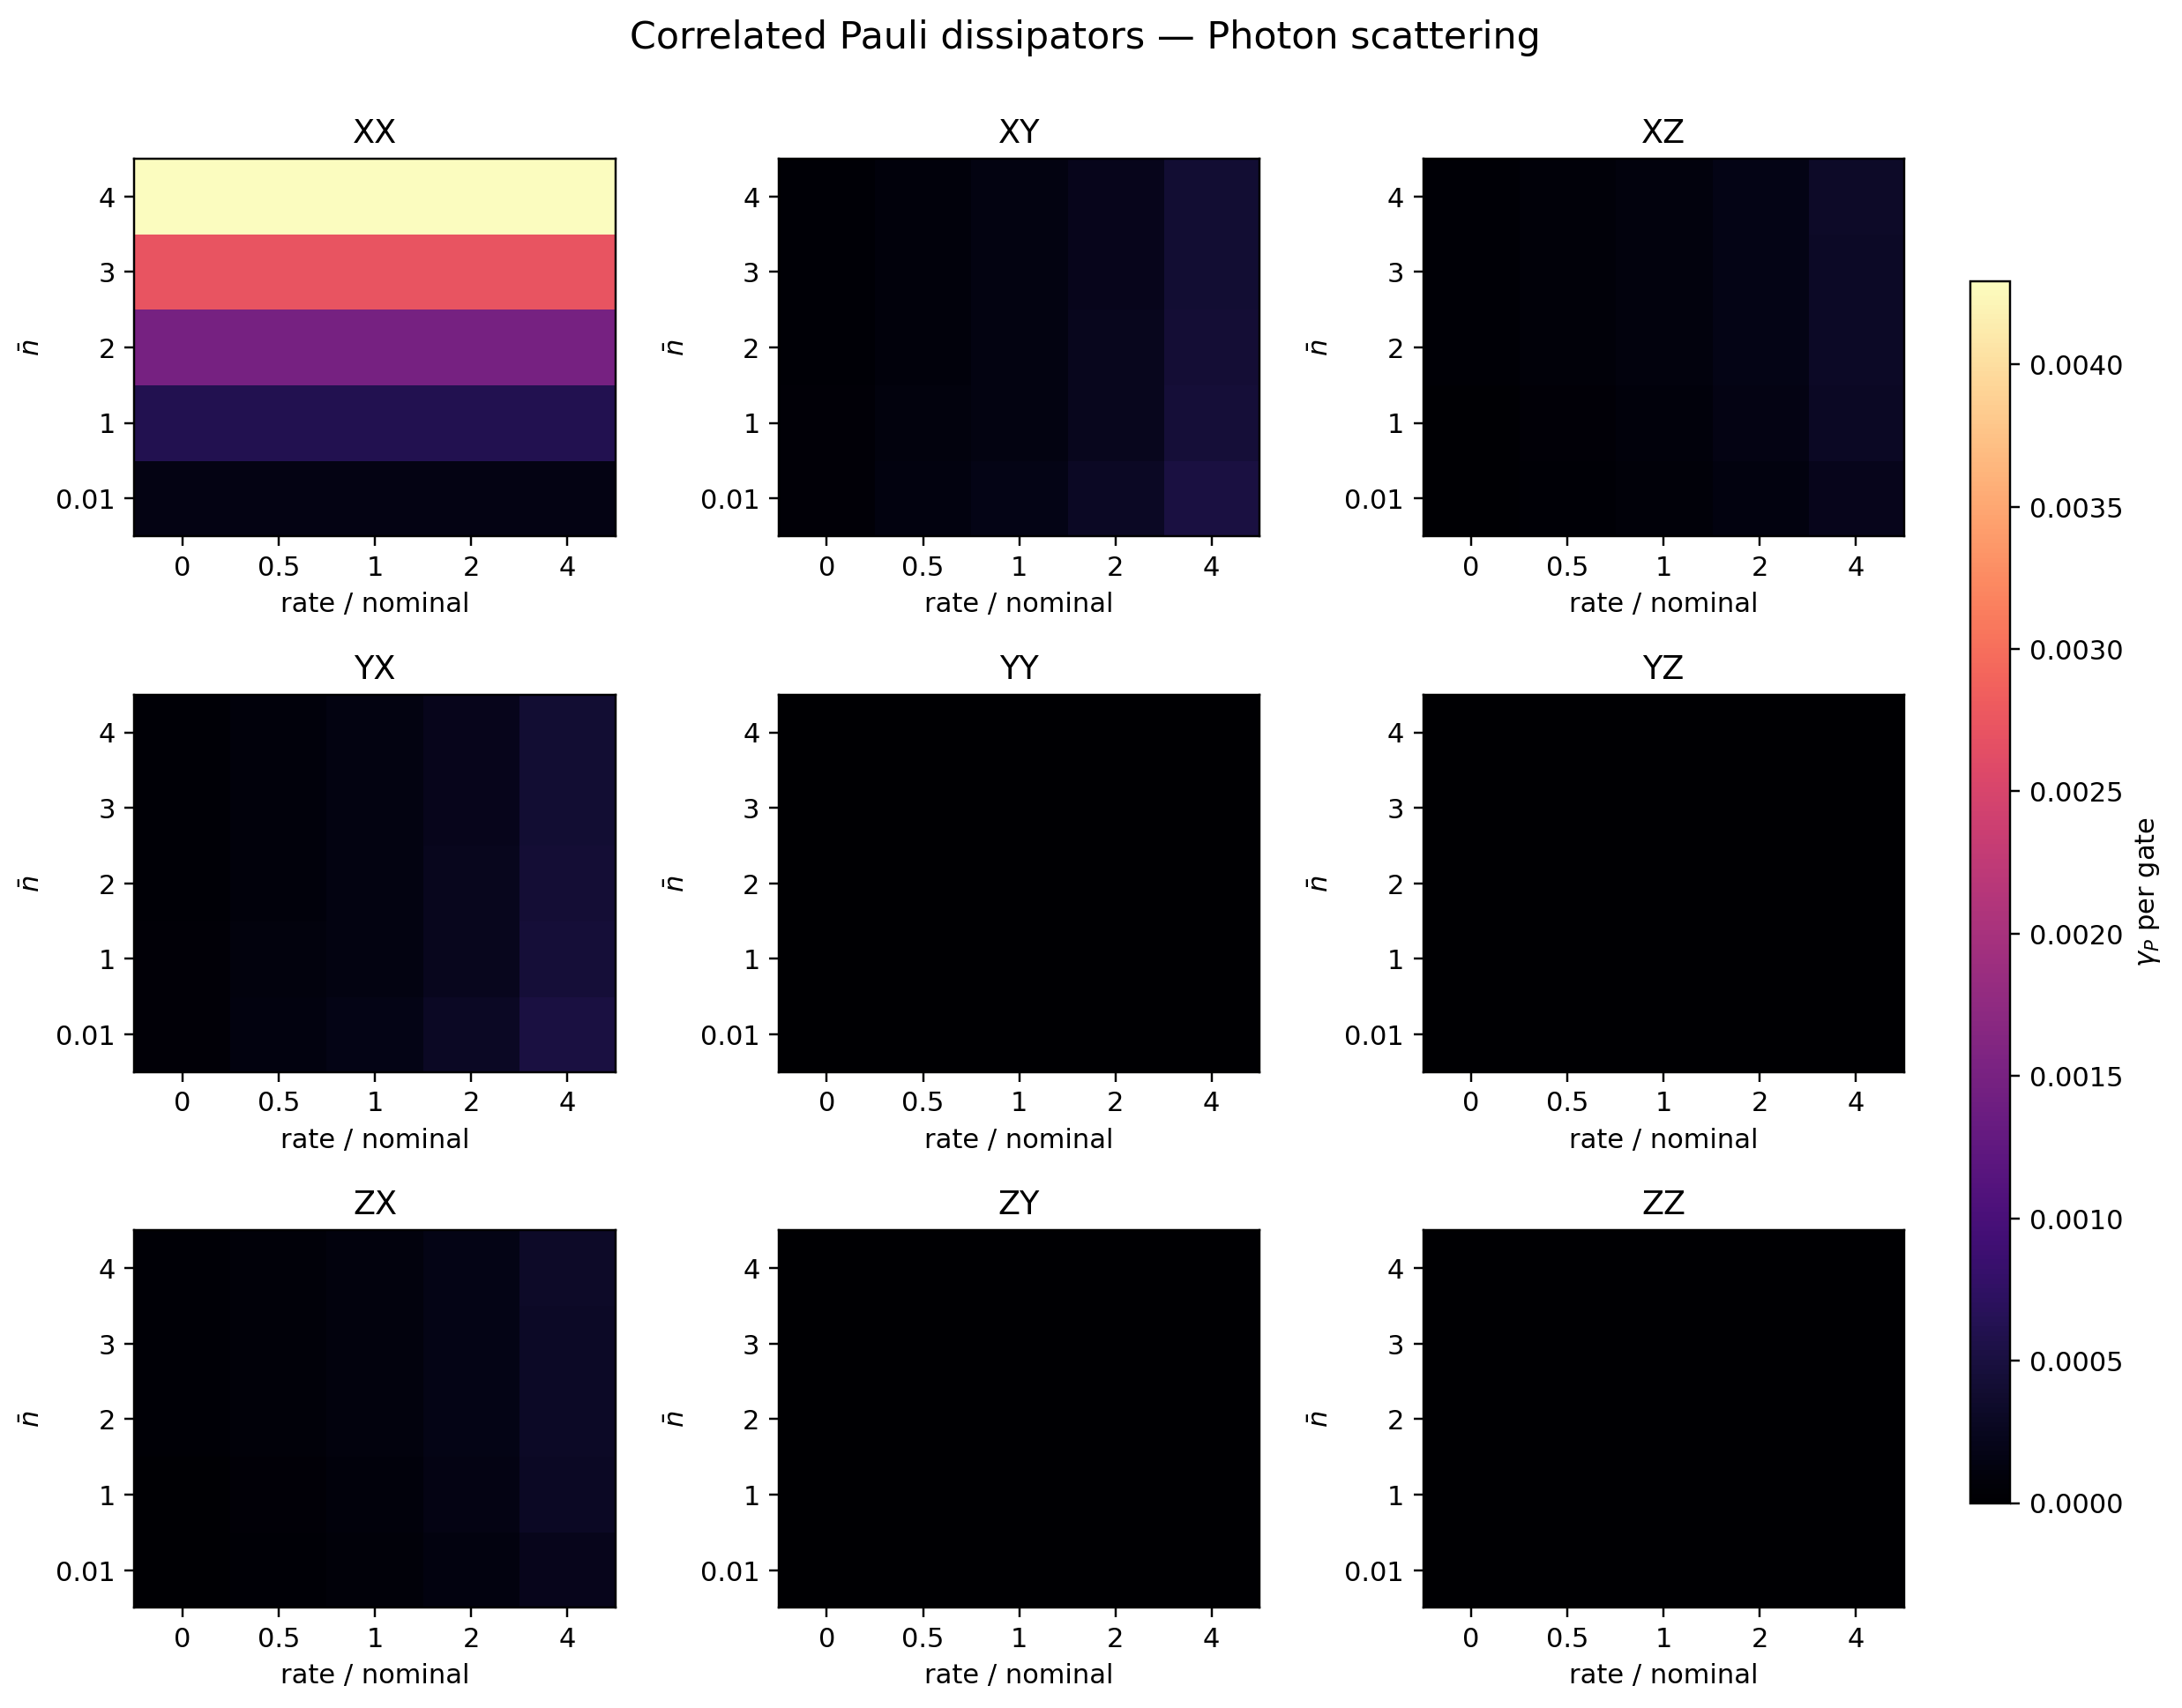

In [20]:
display(Image(filename=str(outputs['xx_figure'])))
for source in egrn.NOISE_SOURCES:
    print(egrn.SOURCE_TITLES[source])
    display(Image(filename=str(outputs['correlated_mode_figures'][source])))


### 3.3 Dominant modeの切替

レートまたは $\bar n$ の増加に伴ってdominant labelが切り替わるかを一覧にする。値はすべてgeneratorから直接得たPauli散逸率である。

In [21]:
mode_trace = summary[[
    'noise_source', 'multiplier', 'nbar',
    'dominant_local_pauli', 'dominant_local_gamma_per_gate',
    'dominant_correlated_pauli', 'dominant_correlated_gamma_per_gate',
    'gamma_XX_per_gate', 'average_infidelity',
]].sort_values(['noise_source', 'multiplier', 'nbar'])
display(mode_trace)

switch_summary = (
    mode_trace.groupby(['noise_source', 'multiplier'], sort=True)
    .agg(
        local_modes=('dominant_local_pauli', lambda s: ' -> '.join(dict.fromkeys(s))),
        correlated_modes=('dominant_correlated_pauli', lambda s: ' -> '.join(dict.fromkeys(s))),
    )
    .reset_index()
)
display(switch_summary)


,noise_source,multiplier,nbar,dominant_local_pauli,dominant_local_gamma_per_gate,dominant_correlated_pauli,dominant_correlated_gamma_per_gate,gamma_XX_per_gate,average_infidelity
0,motional_dephasing,0.0,0.01,IX,0.000329,YX,0.000174,0.000003,0.001464
1,motional_dephasing,0.0,1.00,XI,0.000433,XX,0.000460,0.000460,0.002508
2,motional_dephasing,0.0,2.00,IX,0.000528,XX,0.001336,0.001336,0.004223
3,motional_dephasing,0.0,3.00,XI,0.000611,XX,0.002584,0.002584,0.006537
4,motional_dephasing,0.0,4.00,XI,0.000686,XX,0.004166,0.004166,0.009397
...,...,...,...,...,...,...,...,...,...
95,spin_dephasing,4.0,0.01,XI,0.000551,XY,0.000358,0.000164,0.002744
96,spin_dephasing,4.0,1.00,IX,0.001070,XX,0.000616,0.000616,0.004440
97,spin_dephasing,4.0,2.00,IX,0.001567,XX,0.001485,0.001485,0.006774
98,spin_dephasing,4.0,3.00,IX,0.002034,XX,0.002723,0.002723,0.009668


,noise_source,multiplier,local_modes,correlated_modes
0,motional_dephasing,0.0,IX -> XI,YX -> XX
1,motional_dephasing,0.5,XI -> IX,YX -> XX
2,motional_dephasing,1.0,XI -> IX,XY -> XX
3,motional_dephasing,2.0,IX -> XI,XX
4,motional_dephasing,4.0,IX -> XI,XX
5,motional_heating,0.0,IX -> XI,XY -> XX
6,motional_heating,0.5,XI -> IX,XY -> XX
7,motional_heating,1.0,XI -> IX,XY -> XX
8,motional_heating,2.0,XI -> IX,XY -> XX
9,motional_heating,4.0,IX -> XI,XY -> XX


### 3.4 今回の計算範囲で読める物理

- $\bar n\geq1$ では、4ノイズ軸・全倍率で $XX$ が最大のcorrelated Pauli散逸モードになった。nominal条件では $\gamma_{XX}$ は $\bar n=1$ の $6.16\times10^{-4}$ から $\bar n=4$ の $4.29\times10^{-3}$ まで増加する。
- 低温端 $\bar n=0.01$ では、motional dephasingを0倍から4倍へ増やすと $\gamma_{XX}$ は $2.7\times10^{-6}$ から $6.47\times10^{-4}$ へ増える。今回の4軸のうち、$XX$レート依存が直接明瞭なのはmotional dephasingである。
- Motional heating、spin dephasing、photon scatteringを変えても、$\bar n=4$ の $\gamma_{XX}$ はほぼ $4.29\times10^{-3}$ のままである。これらのレート依存は主にlocal mode、または低温端の $XY/YX$ modeへ現れる。
- 4倍・$\bar n=4$ では、motional dephasingのdominant local rateは $7.69\times10^{-3}$、$\gamma_{XX}=4.78\times10^{-3}$ であり、local散逸の増加も無視できない。
- したがって、この結果は「熱運動に伴う共通の$XX$散逸」と「ノイズ源固有のlocal／低温correlated成分」を分離して見せる。ただし、これだけで相関浴を同定したことにはならない。

## 4. 保存物と次の判定

- `channel_cache/*.npz`: trace-normalized error-channel $\chi$
- `generator_summary.csv`: 4軸 $\times$ 5倍率 $\times$ 5個の $\bar n$ の要約
- `generator_pauli_coefficients.csv`: 全15 Pauliの $h_P,\gamma_P$
- `dominant_pauli_modes_top3.csv`: local/correlated各上位3モード
- `gamma_xx_vs_nbar_by_noise_rate.png` と `correlated_mode_maps/*.png`: 主要図

この結果から、どの二体Pauli散逸モードがどのノイズ軸で増えるかまでは判定できる。一方、相関浴モデルを導入する判断には、物理的に対応する散逸機構とモードの再現性を確認してから進む。

## 5. 上位3ノイズペアのcomponent-resolved interaction

既存の全6ペア $5\times5$ infidelity gridについて

$$C_{ij}^{(I)}=I_{ij}-I_i-I_j+I_0$$

を評価する。正ならsuper-additiveなerror増強、負ならsub-additiveである。今回のactive gridでは全ペアが負だったため、符号を残したまま $\max|C_{ij}^{(I)}|$ が大きい順に並べる。上位3ペアについてのみfull error channelを保存し、各Pauli generator成分にも同じ差分を適用する。

In [22]:
import pairwise_error_generator as peg
peg = importlib.reload(peg)

PAIRWISE_SCALAR_PATH = Path(
    'results/noise_rate_nbar_sweep/all_pairwise_5x5_grids/'
    'all_pairwise_grid_interactions.csv'
)
scalar_pairwise_interactions = pd.read_csv(PAIRWISE_SCALAR_PATH)
pair_ranking = peg.rank_pairwise_infidelity_interactions(
    scalar_pairwise_interactions
)
TOP_PAIR_IDS = tuple(pair_ranking.head(3)['pair_id'])
pair_ranking.to_csv(
    OUTPUT_DIR / 'pairwise_infidelity_Cij_ranking.csv', index=False
)
display(pair_ranking[[
    'rank', 'pair_id', 'signed_C_at_max_abs', 'max_abs_C',
    'has_positive_enhancement', 'nbar_at_max_abs',
    'multiplier_x_at_max_abs', 'multiplier_y_at_max_abs',
    'relative_C_at_max_abs',
]])
print('Selected top-3 pairs:', TOP_PAIR_IDS)


,rank,pair_id,signed_C_at_max_abs,max_abs_C,has_positive_enhancement,nbar_at_max_abs,multiplier_x_at_max_abs,multiplier_y_at_max_abs,relative_C_at_max_abs
0,1,motional_heating__motional_dephasing,-0.000044,0.000044,False,4.00,4.0,4.0,-0.003466
1,2,motional_dephasing__photon_scattering,-0.000033,0.000033,False,4.00,4.0,4.0,-0.002421
2,3,motional_dephasing__spin_dephasing,-0.000015,0.000015,False,4.00,4.0,4.0,-0.001219
3,4,motional_heating__photon_scattering,-0.000005,0.000005,False,0.01,4.0,4.0,-0.001198
4,5,spin_dephasing__photon_scattering,-0.000004,0.000004,False,0.01,4.0,4.0,-0.001080
5,6,motional_heating__spin_dephasing,-0.000002,0.000002,False,0.01,4.0,4.0,-0.000796


Selected top-3 pairs: ('motional_heating__motional_dephasing', 'motional_dephasing__photon_scattering', 'motional_dephasing__spin_dephasing')


### 5.1 Pairwise error-channel QPT

各ペアでは2つの対象ノイズだけをgrid上で変化させ、残り2ノイズは0にする。これは既存の $C_{ij}^{(I)}$ と同じreference conventionである。3 gridのzero点とsingle-axis点はcondition IDで共有し、75表示条件を65一意条件へ縮約する。

重い計算なので初期値は `EXECUTE_PAIRWISE_QPT=False` とした。実行時だけ `True` に変更する。各channel点はNPZへ保存され、中断後は未計算点だけ再開される。

In [23]:
PAIRWISE_OUTPUT_DIR = OUTPUT_DIR / 'top3_pairwise_generator'
EXECUTE_PAIRWISE_QPT = True
PAIRWISE_RESUME = True

selected_pair_plan = peg.build_selected_pairwise_plan(
    BASE_PARAMETERS, TOP_PAIR_IDS, RATE_MULTIPLIERS
)
unique_conditions = len(selected_pair_plan['catalog'])
channel_points = unique_conditions * len(NBAR_VALUES)
me_evolutions = (
    channel_points * BASE_PARAMETERS['laser_noise_samples'] * 16
)
print(f'Selected pairs: {len(TOP_PAIR_IDS)}')
print(f'Displayed pair-grid conditions: {len(selected_pair_plan["requests"])}')
print(f'Unique physical conditions: {unique_conditions}')
print(f'Error-channel points: {channel_points}')
print(f'ME evolutions before cache reuse: {me_evolutions}')
display(selected_pair_plan['catalog'])


Selected pairs: 3
Displayed pair-grid conditions: 75
Unique physical conditions: 65
Error-channel points: 325
ME evolutions before cache reuse: 5200


,condition_id,motional_heating_s^-1,motional_dephasing_s^-1,spin_dephasing_s^-1,photon_scattering_s^-1,is_all_noise_zero
0,rates_7283b228c09abbcb,0.0,0.0,0.000000,0.0,True
1,rates_043985184c08dfb1,0.0,72.0,6.666667,0.0,False
2,rates_0e752ad71c6095d9,40.0,0.0,0.000000,0.0,False
3,rates_10ba39339e235ff4,0.0,36.0,0.000000,8.0,False
4,rates_10c0db9943c7239f,0.0,72.0,0.000000,2.0,False
...,...,...,...,...,...,...
60,rates_de7c92c5d91f74df,0.0,18.0,0.000000,16.0,False
61,rates_e3c1dfd931a34ad1,0.0,18.0,13.333333,0.0,False
62,rates_e627b957213b2032,0.0,72.0,0.000000,0.0,False
63,rates_f178564d2b994859,0.0,9.0,3.333333,0.0,False


In [24]:
pairwise_sweep = peg.run_or_load_selected_pairwise_qpt(
    output_dir=PAIRWISE_OUTPUT_DIR,
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    pair_ids=TOP_PAIR_IDS,
    rate_multipliers=RATE_MULTIPLIERS,
    convention='undo_before_actual',
    execute=EXECUTE_PAIRWISE_QPT,
    resume=PAIRWISE_RESUME,
)
print(
    f"Cached pairwise channel points: "
    f"{pairwise_sweep['completed_point_count']}/"
    f"{pairwise_sweep['total_point_count']}"
)
print(
    f"Pending ME evolutions: "
    f"{pairwise_sweep['pending_master_equation_evolutions']}"
)
if not pairwise_sweep['pending'].empty:
    display(pairwise_sweep['pending'])


Run pairwise error-channel QPT 41/65: rates_81677bfe42e2c55f, nbar=(0.01, 1.0, 2.0, 3.0, 4.0)


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/80 [00:00<?, ?evolution/s]

Run pairwise error-channel QPT 42/65: rates_87cf81c0f802ee14, nbar=(0.01, 1.0, 2.0, 3.0, 4.0)


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/80 [00:00<?, ?evolution/s]

Run pairwise error-channel QPT 43/65: rates_8c12b1161e3632d1, nbar=(0.01, 1.0, 2.0, 3.0, 4.0)


...

Run pairwise error-channel QPT 64/65: rates_f178564d2b994859, nbar=(0.01, 1.0, 2.0, 3.0, 4.0)


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/80 [00:00<?, ?evolution/s]

Run pairwise error-channel QPT 65/65: rates_fb241267f5ea81c6, nbar=(0.01, 1.0, 2.0, 3.0, 4.0)


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/80 [00:00<?, ?evolution/s]

Cached pairwise channel points: 325/325
Pending ME evolutions: 0


### 5.2 全Pauli generator分解と成分別interaction

各channelから全15個の $h_P,\gamma_P$ を抽出し、Pauli成分ごとに

$$C_{ij}^{(P)}=\gamma_P(i,j)-\gamma_P(i,0)-\gamma_P(0,j)+\gamma_P(0,0)$$

を計算する。$C_{ij}^{(P)}>0$ はそのPauli散逸成分のsuper-additiveな増強、負はsub-additiveを意味する。これはerror-channel上の非加法性であり、相関浴の直接同定ではない。

In [31]:
pairwise_generators = None
pairwise_generator_outputs = None
if pairwise_sweep['complete']:
    pairwise_generators = peg.extract_pairwise_generators(pairwise_sweep)
    pairwise_generator_outputs = peg.save_pairwise_generator_outputs(
        pairwise_sweep, pairwise_generators
    )
    print(
        f"Generator channel rows: {len(pairwise_generators['summary'])}"
    )
    print(
        'Component interaction rows: '
        f"{len(pairwise_generator_outputs['interactions'])}"
    )
else:
    print(
        'Pairwise QPT is incomplete. Set EXECUTE_PAIRWISE_QPT=True '
        'and rerun Sections 5.1--5.2.'
    )


Extract pairwise generator 1/325: rates_043985184c08dfb1, nbar=0.01
Extract pairwise generator 2/325: rates_043985184c08dfb1, nbar=1
Extract pairwise generator 3/325: rates_043985184c08dfb1, nbar=2
Extract pairwise generator 4/325: rates_043985184c08dfb1, nbar=3
Extract pairwise generator 5/325: rates_043985184c08dfb1, nbar=4
Extract pairwise generator 6/325: rates_0e752ad71c6095d9, nbar=0.01
Extract pairwise generator 7/325: rates_0e752ad71c6095d9, nbar=1
Extract pairwise generator 8/325: rates_0e752ad71c6095d9, nbar=2
Extract pairwise generator 9/325: rates_0e752ad71c6095d9, nbar=3
Extract pairwise generator 10/325: rates_0e752ad71c6095d9, nbar=4
Extract pairwise generator 11/325: rates_10ba39339e235ff4, nbar=0.01
Extract pairwise generator 12/325: rates_10ba39339e235ff4, nbar=1
Extract pairwise generator 13/325: rates_10ba39339e235ff4, nbar=2
Extract pairwise generator 14/325: rates_10ba39339e235ff4, nbar=3
Extract pairwise generator 15/325: rates_10ba39339e235ff4, nbar=4
Extract pa

,pair_id,rank_within_pair,pauli,mode_class,signed_interaction_gamma_at_max_abs,max_abs_interaction_gamma,nbar_at_max_abs,multiplier_x_at_max_abs,multiplier_y_at_max_abs
0,motional_dephasing__photon_scattering,1,ZI,local,8.764080e-07,8.764080e-07,4.0,4.0,4.0
1,motional_dephasing__photon_scattering,2,IZ,local,8.757579e-07,8.757579e-07,4.0,4.0,4.0
2,motional_dephasing__photon_scattering,3,ZX,correlated,-8.595189e-07,8.595189e-07,4.0,4.0,4.0
3,motional_dephasing__photon_scattering,4,XZ,correlated,-8.572717e-07,8.572717e-07,4.0,4.0,4.0
4,motional_dephasing__photon_scattering,5,IY,local,-6.529273e-07,6.529273e-07,4.0,4.0,4.0
5,motional_dephasing__photon_scattering,6,YI,local,-6.522866e-07,6.522866e-07,4.0,4.0,4.0
6,motional_dephasing__photon_scattering,7,XY,correlated,6.320207e-07,6.320207e-07,4.0,4.0,4.0
7,motional_dephasing__photon_scattering,8,YX,correlated,6.282746e-07,6.282746e-07,4.0,4.0,4.0
8,motional_dephasing__photon_scattering,9,IX,local,6.374852e-08,6.374852e-08,3.0,0.5,1.0
9,motional_dephasing__photon_scattering,10,XX,correlated,5.245578e-08,5.245578e-08,3.0,4.0,2.0


motional_heating__motional_dephasing


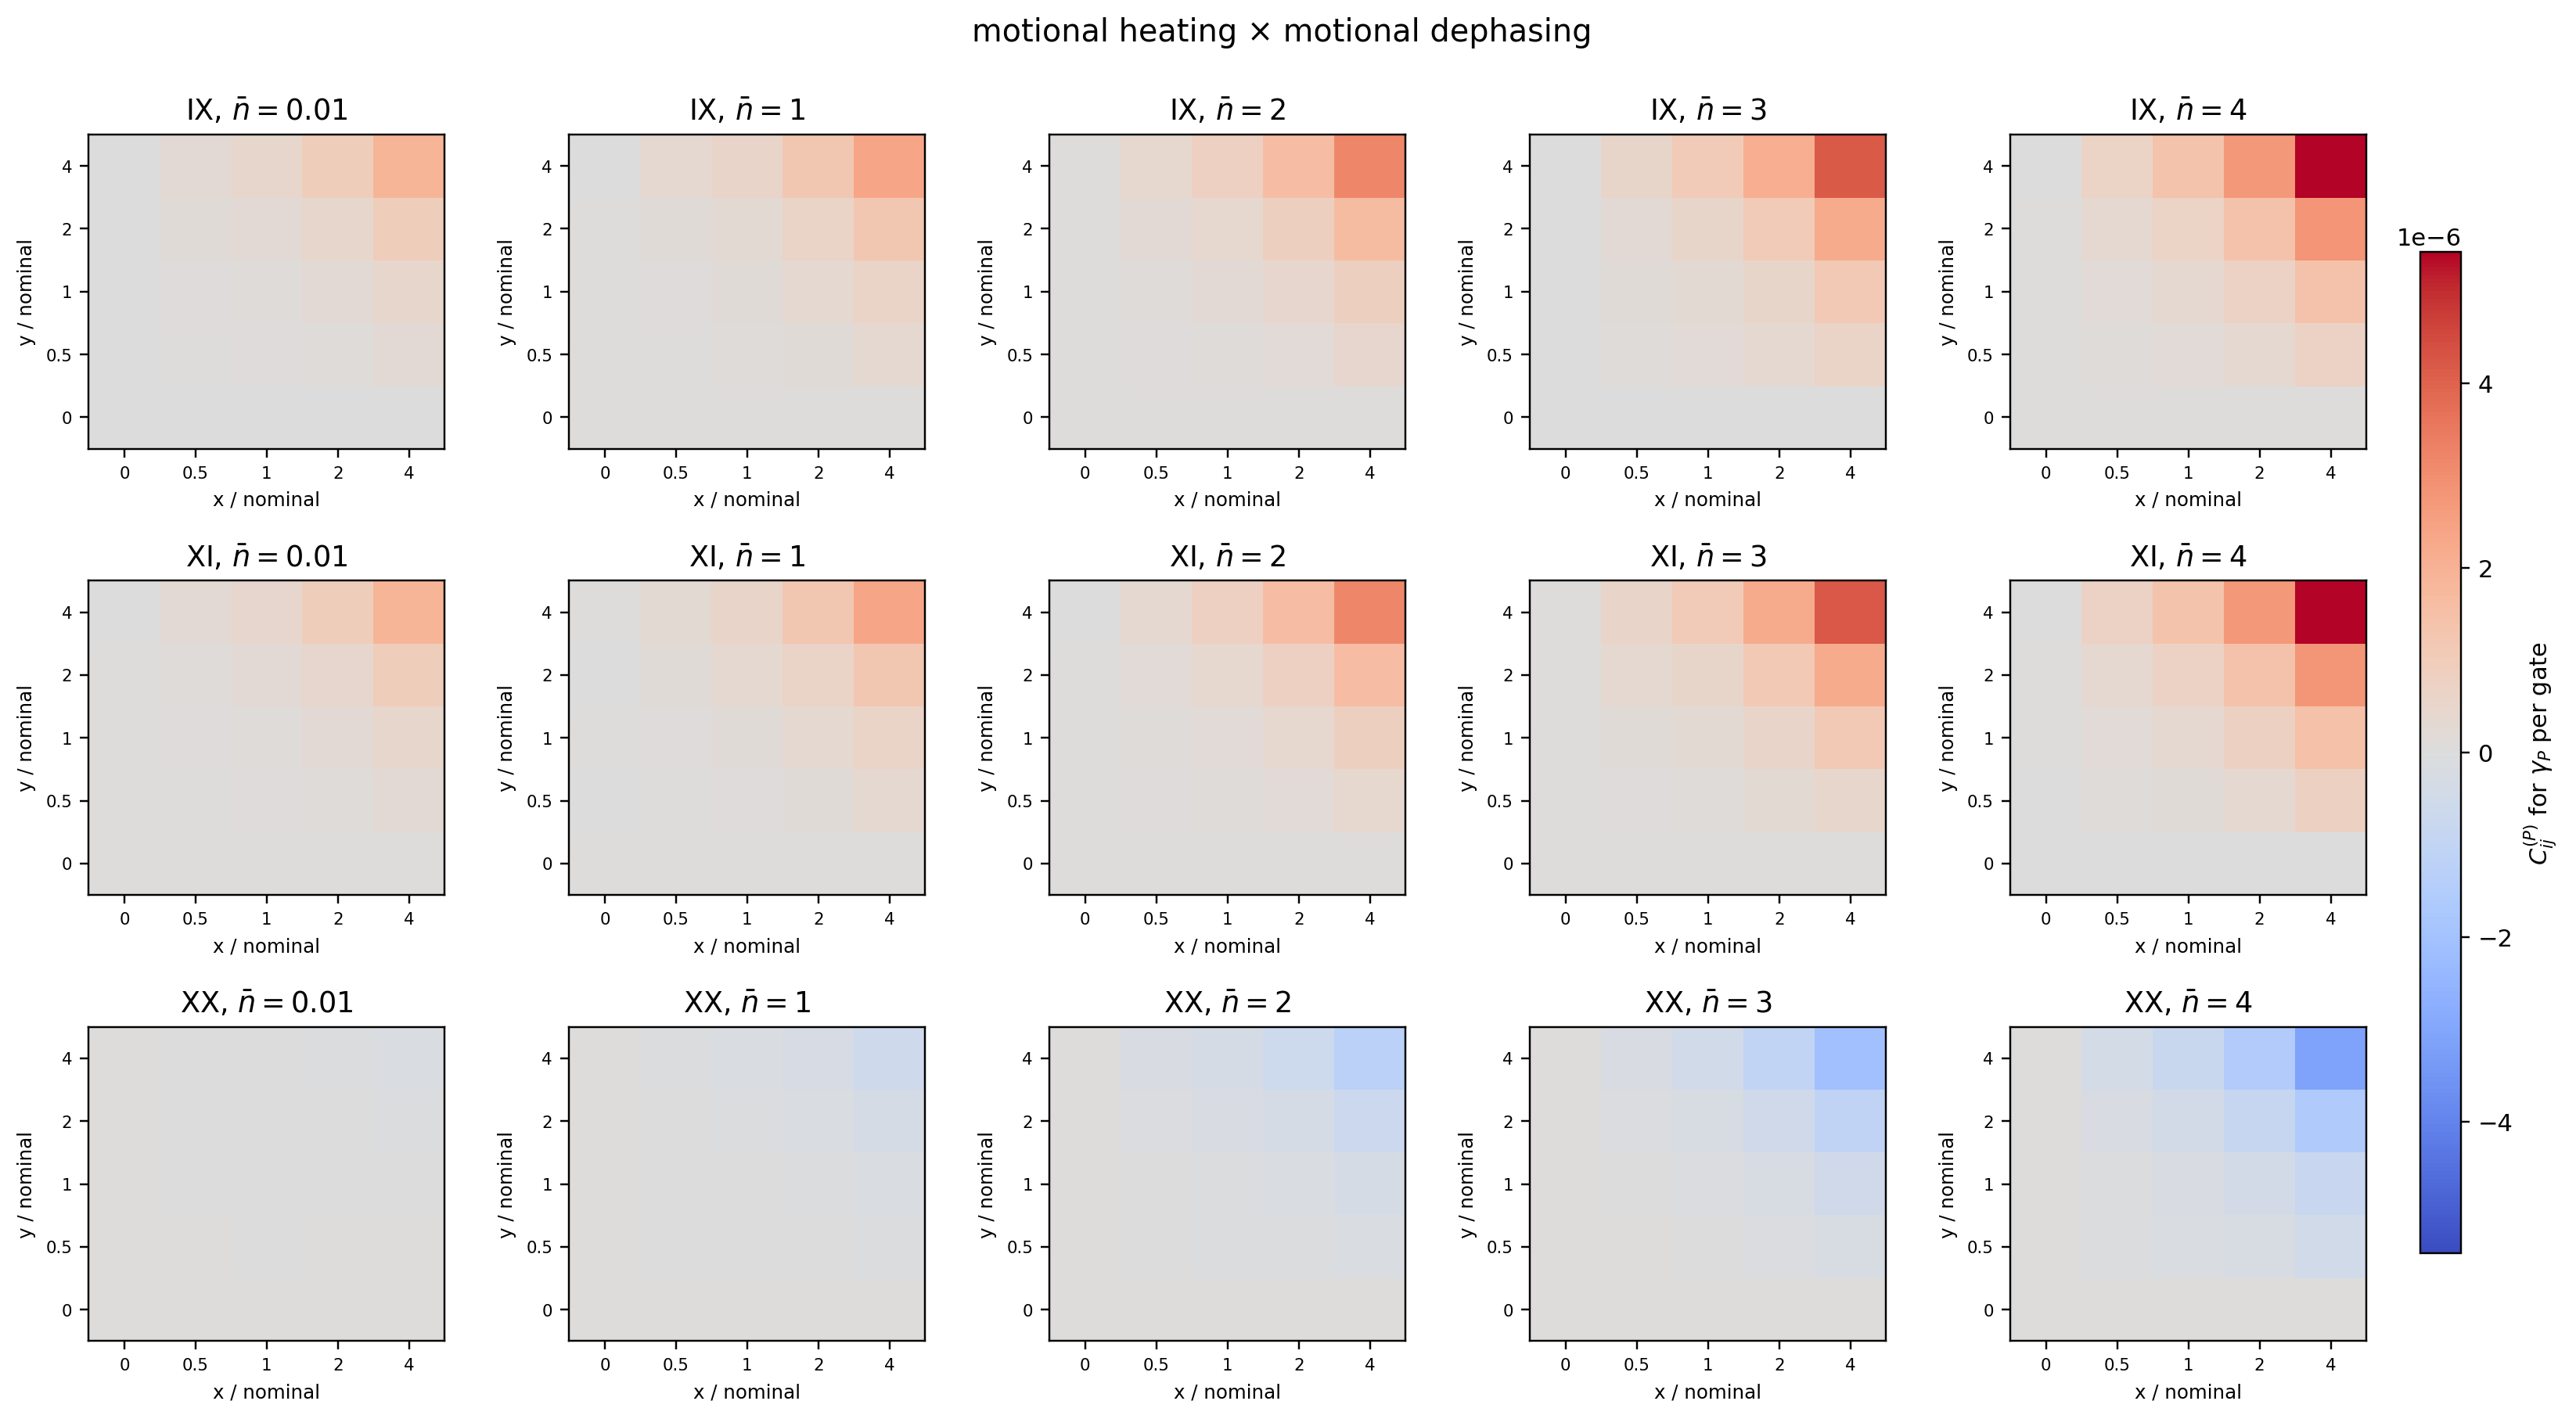

motional_dephasing__photon_scattering


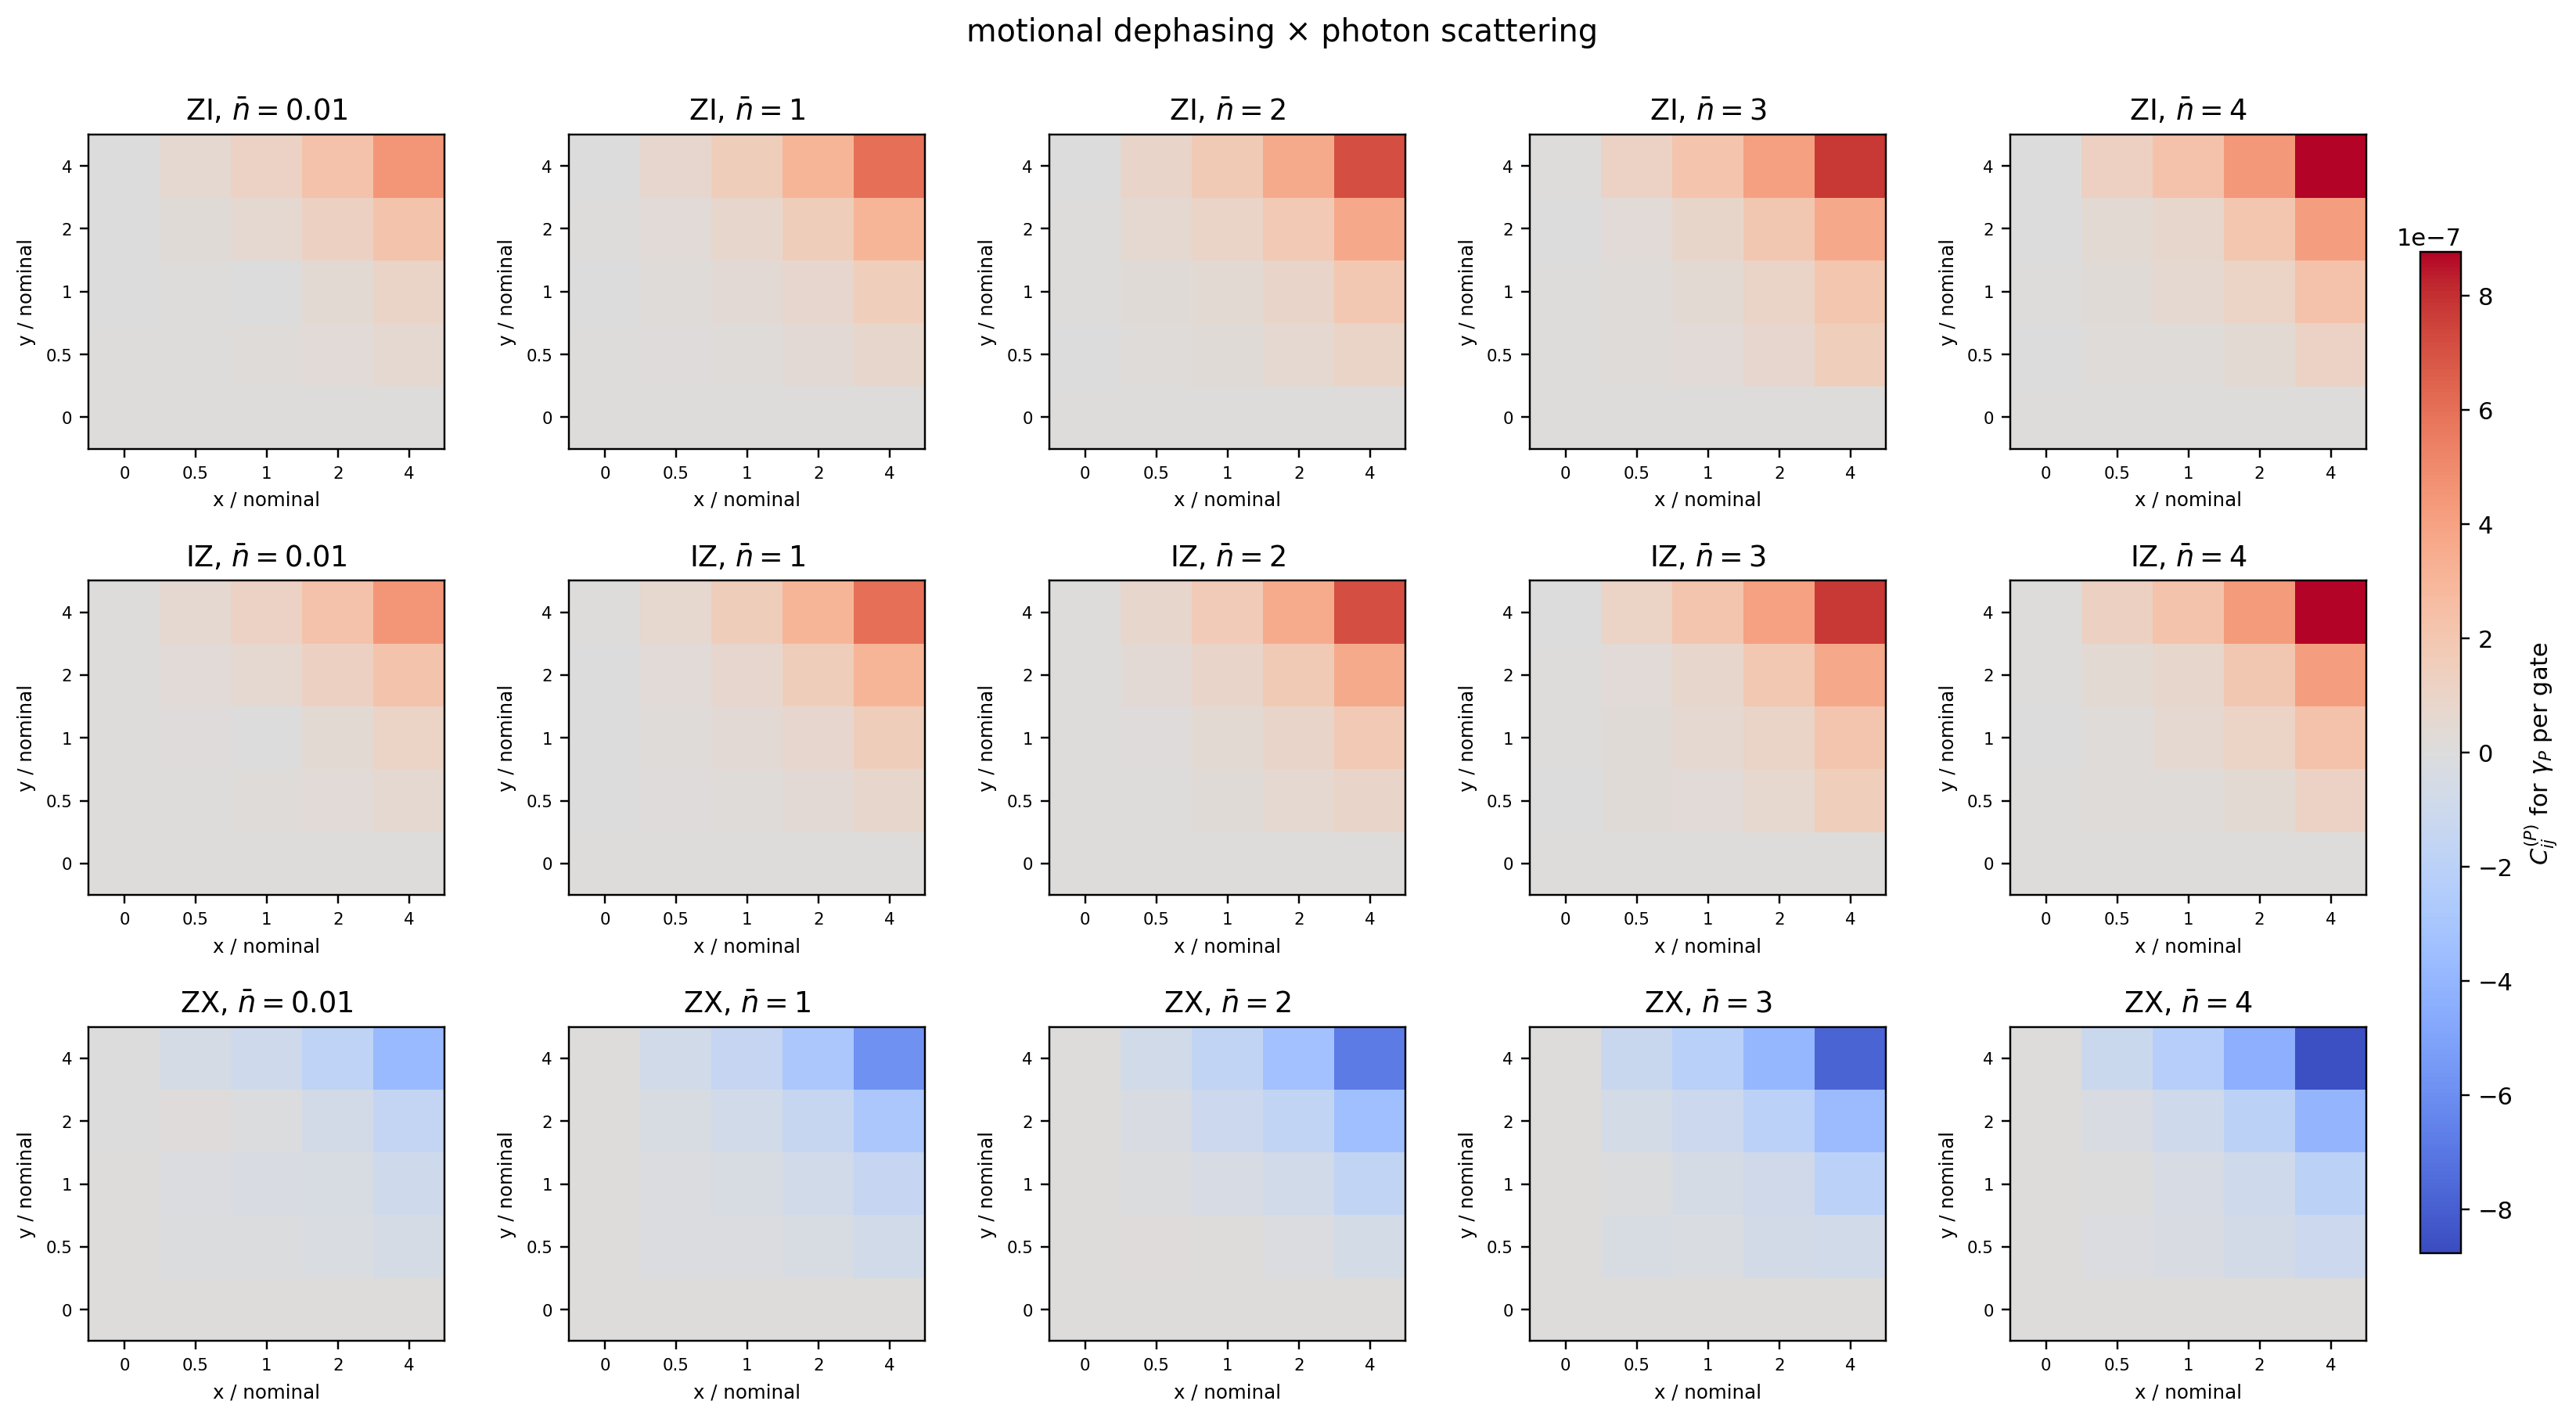

motional_dephasing__spin_dephasing


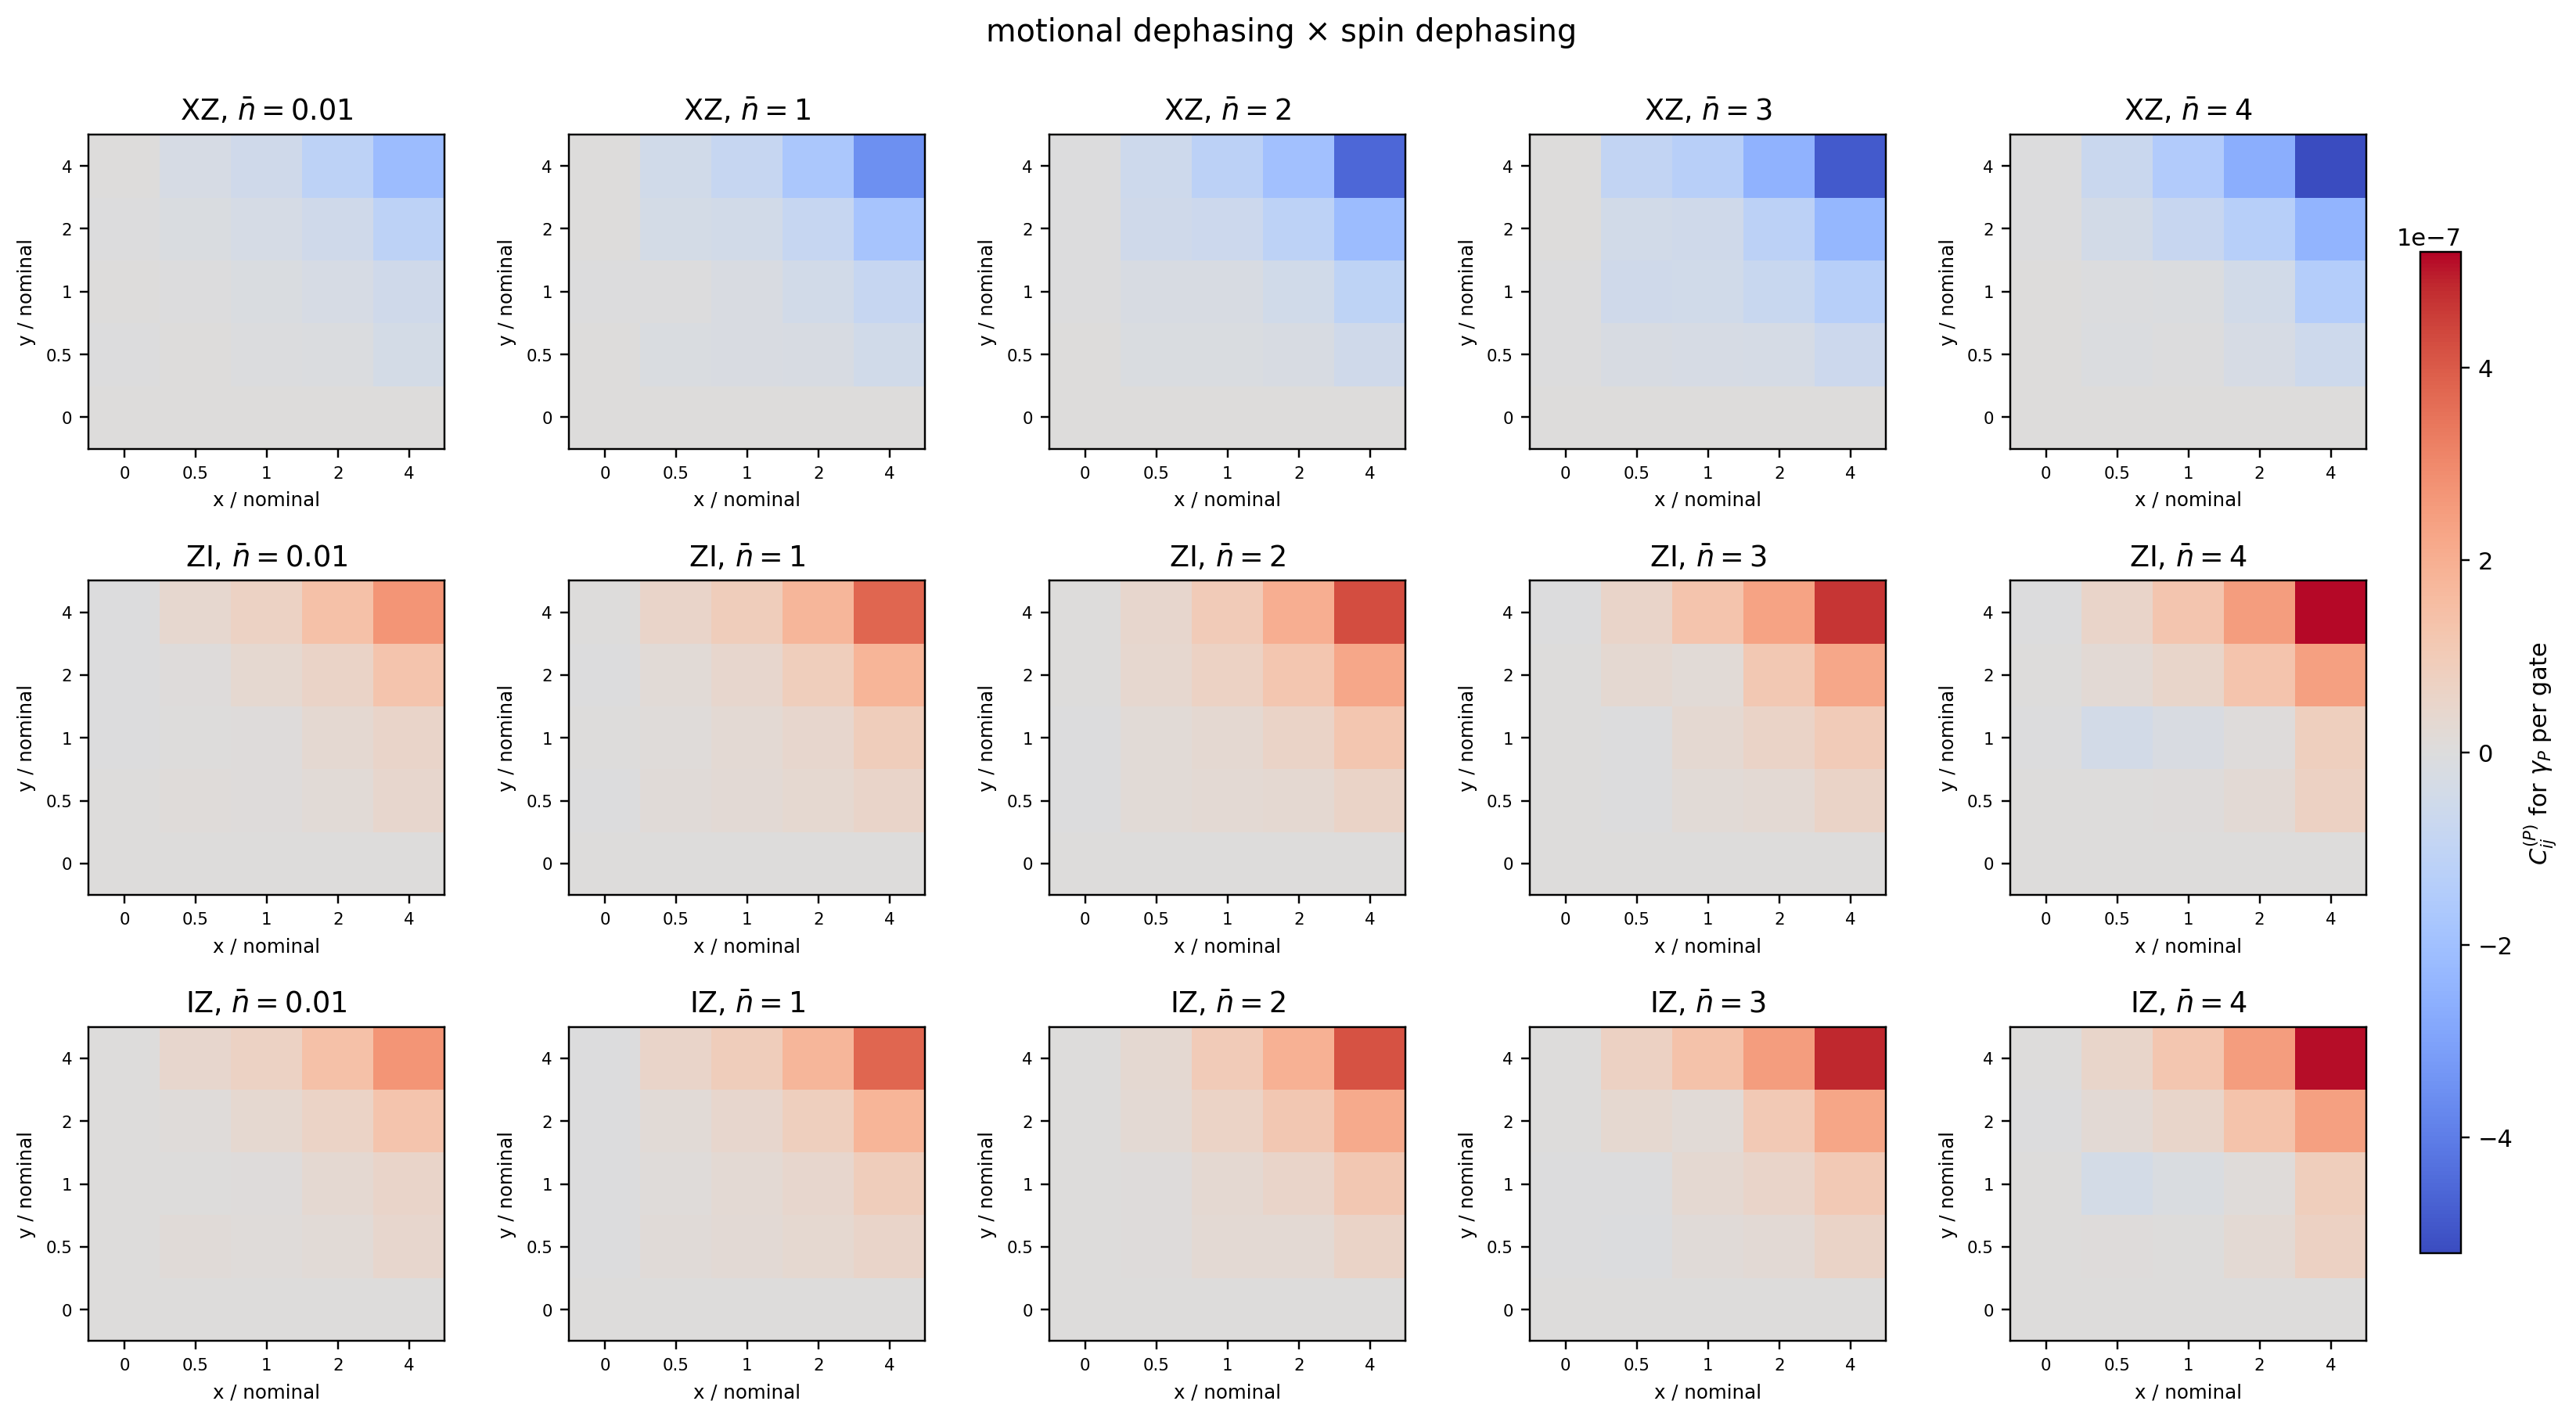

In [26]:
if pairwise_generator_outputs is not None:
    component_ranking = pairwise_generator_outputs['ranking']
    display(component_ranking[
        component_ranking['rank_within_pair'].le(10)
    ][[
        'pair_id', 'rank_within_pair', 'pauli', 'mode_class',
        'signed_interaction_gamma_at_max_abs',
        'max_abs_interaction_gamma', 'nbar_at_max_abs',
        'multiplier_x_at_max_abs', 'multiplier_y_at_max_abs',
    ]])
    for pair_id in TOP_PAIR_IDS:
        print(pair_id)
        display(Image(filename=str(
            pairwise_generator_outputs['figures'][pair_id]
        )))


### 5.3 保存物

`results/error_generator_rate_nbar/top3_pairwise_generator/` に以下を保存する。

- `channel_cache/*.npz`: 325個のtrace-normalized error channel
- `pairwise_generator_summary.csv`: 各一意channelのgenerator診断量
- `pairwise_generator_pauli_coefficients.csv`: 全15個の $h_P,\gamma_P$
- `pairwise_generator_interactions.csv`: 各grid点の成分別 $C_{ij}^{(P)}$
- `pairwise_generator_interaction_ranking.csv`: ペアごとのPauli成分順位
- `interaction_mode_maps/*.png`: 上位3成分の $5\times5$ interaction map


## 6. Heating $\times$ motional dephasing：既存データだけの3モデル

Section 5のQPTを新たに回さず、保存済みのinfidelity gridと単一ノイズのgenerator係数だけを使う。まず観測値

$$C_{hd}=I_{hd}-I_h-I_d+I_0$$

から、独立な2つの誤差を同時にかけただけでaverage infidelityに現れる非線形な重なり

$$C_{hd}^{\mathrm{ind}}=-\frac{4}{3}\Delta I_h\Delta I_d$$

を引き、$C_{hd}^{\mathrm{extra}}=C_{hd}-C_{hd}^{\mathrm{ind}}$を3通りにモデル化する。ここでの目的は「相関浴の証明」ではなく、今あるデータのどの特徴が追加補正を説明するかを切り分けることである。


In [27]:
import heating_dephasing_models as hdm
hdm = importlib.reload(hdm)

HD_PAIR_GRID_PATH = Path(
    'results/noise_rate_nbar_sweep/all_pairwise_5x5_grids/'
    'all_pairwise_grid_interactions.csv'
)
HD_GENERATOR_PATH = Path(
    'results/error_generator_rate_nbar/generator_pauli_coefficients.csv'
)
HD_MODEL_OUTPUT_DIR = Path(
    'results/noise_rate_nbar_sweep/heating_dephasing_models'
)

hd_models = hdm.run_existing_data_models(
    pair_interactions_path=HD_PAIR_GRID_PATH,
    generator_coefficients_path=HD_GENERATOR_PATH,
    output_dir=HD_MODEL_OUTPUT_DIR,
)
print('No master-equation evolution was performed in Section 6.')
print(f'Output directory: {HD_MODEL_OUTPUT_DIR}')


No master-equation evolution was performed in Section 6.
Output directory: results/noise_rate_nbar_sweep/heating_dephasing_models


### 6.1 Model 1：ノイズ倍率の積

各 $\bar n$ で

$$C_{hd}^{\mathrm{extra}}=-\kappa(\bar n)m_hm_d$$

とフィットする。$m_hm_d$は「heatingとmotional dephasingが両方あるときだけ出る効果」の最も簡単な形である。$\kappa(\bar n)$が増えるから、同じノイズ倍率でも熱運動が多いほど追加補正が大きいと読める。


,nbar,kappa_extra_per_multiplier_product,rmse,max_abs_residual,nrmse_to_max_abs_extra,correlation
0,0.01,6.276946e-08,1.398621e-08,2.471867e-08,0.013909,0.998500
1,1.00,4.749037e-07,1.575350e-08,3.028494e-08,0.002081,0.999977
2,2.00,8.331107e-07,3.960722e-08,7.981191e-08,0.002989,0.999960
3,3.00,1.134656e-06,5.291429e-08,1.117368e-07,0.002930,0.999947
4,4.00,1.404733e-06,9.149463e-08,1.755846e-07,0.004097,0.999917


,nbar,interaction_infidelity,independent_overlap,extra_interaction,model1_extra_prediction
24,0.01,-0.000005,-0.000004,-0.000001,-0.000001
49,1.00,-0.000017,-0.000009,-0.000008,-0.000008
74,2.00,-0.000027,-0.000014,-0.000013,-0.000013
99,3.00,-0.000036,-0.000018,-0.000018,-0.000018
124,4.00,-0.000044,-0.000021,-0.000022,-0.000022


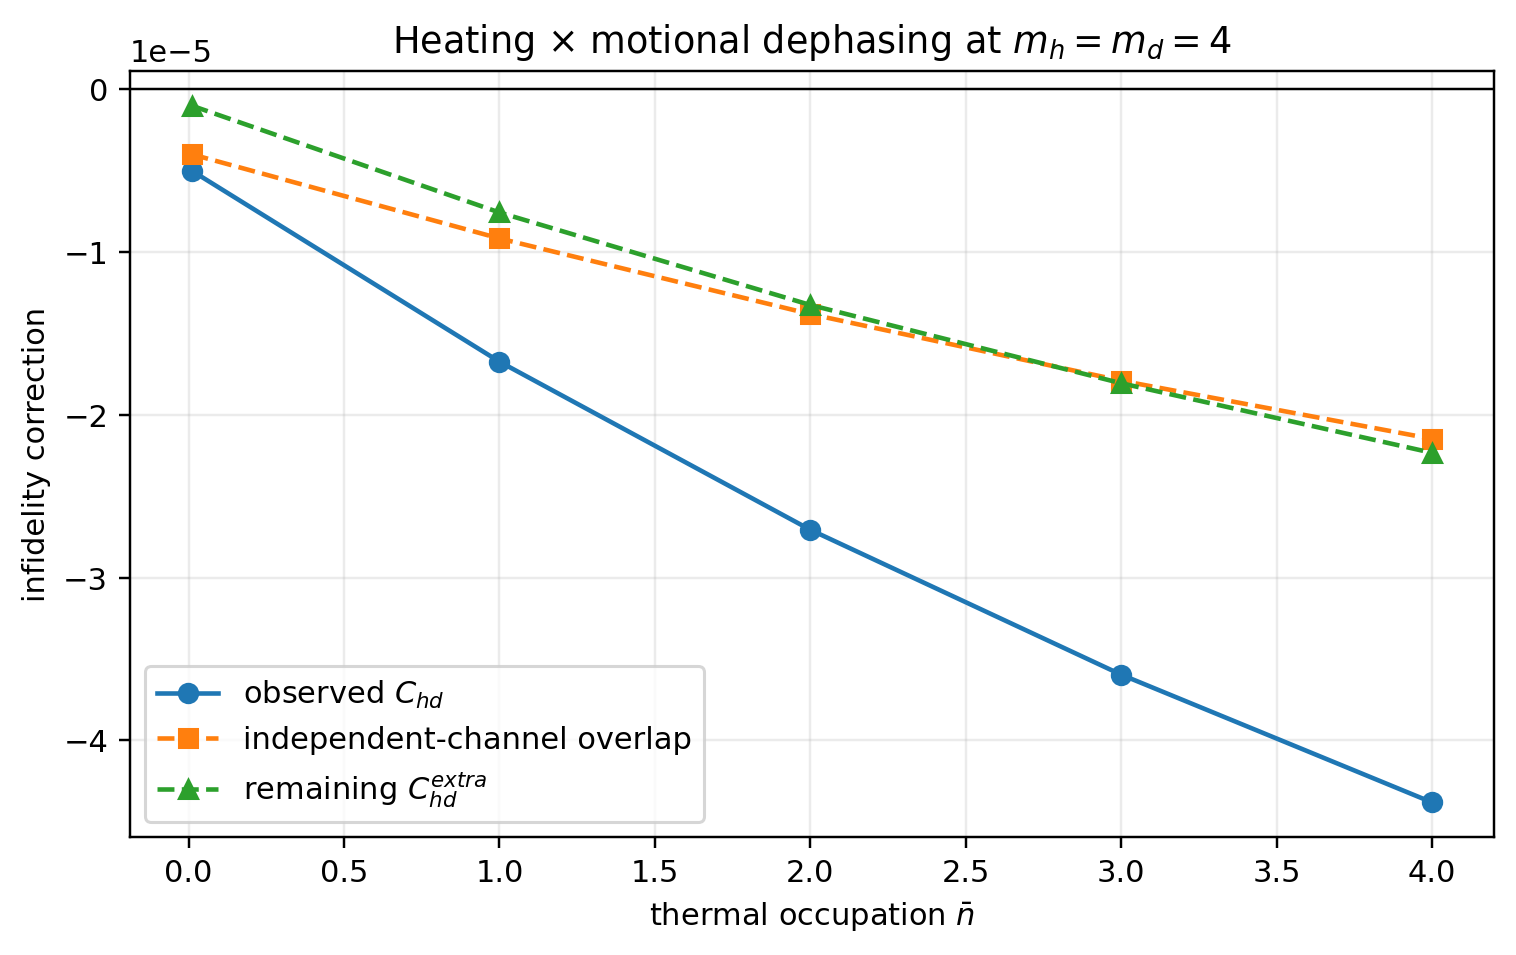

In [28]:
display(hd_models['model1_fit'])

endpoint = hd_models['grid'][
    np.isclose(hd_models['grid']['multiplier_x'], 4.0)
    & np.isclose(hd_models['grid']['multiplier_y'], 4.0)
].sort_values('nbar')
display(endpoint[[
    'nbar', 'interaction_infidelity', 'independent_overlap',
    'extra_interaction', 'model1_extra_prediction',
]])
display(Image(filename=str(hd_models['paths']['decomposition_figure'])))


### 6.2 Model 2：同じPauli散逸モードの重なり

単一ノイズ計算で保存済みの $\gamma_P$ を使い、

$$O_\gamma=\sum_P\Delta\gamma_P^{(h)}\Delta\gamma_P^{(d)},\qquad C_{hd}^{\mathrm{extra}}=s_\gamma O_\gamma$$

とする。これは「2つのノイズが同じエラーの向きを強めているか」を見るモデルである。どの $P$ が大きいかを表示し、単なるフィット以上の物理的な中身を与える。

> 注意：このモデルの単一ノイズ軸では、他の3ノイズはnominal値である。したがってSection 5の2ノイズQPTと同一のチャネル分解ではなく、既存データから作る説明モデルである。


,pauli,delta_gamma_heating,delta_gamma_motional_dephasing,gamma_mode_product,gamma_overlap_fraction
1819,XI,9.036726e-04,7.001417e-03,6.326989e-06,4.999207e-01
1804,IX,9.036715e-04,7.001419e-03,6.326983e-06,4.999202e-01
1824,XX,3.254317e-06,6.185479e-04,2.012951e-09,1.590513e-04
1864,ZX,-1.044788e-09,-3.386783e-07,3.538470e-16,2.795886e-11
1829,XY,5.965319e-10,2.570396e-07,1.533323e-16,1.211540e-11
1834,XZ,-2.816820e-11,-3.460163e-07,9.746657e-18,7.701224e-13
1849,YY,6.613372e-09,0.000000e+00,0.000000e+00,0.000000e+00
1854,YZ,0.000000e+00,-5.416322e-09,-0.000000e+00,-0.000000e+00


,scope,nbar,gamma_overlap_scale
0,all,NaN,-1.735233
1,nbar,0.01,-0.581688
2,nbar,1.00,-1.568100
3,nbar,2.00,-1.727944
4,nbar,3.00,-1.757839
5,nbar,4.00,-1.768576


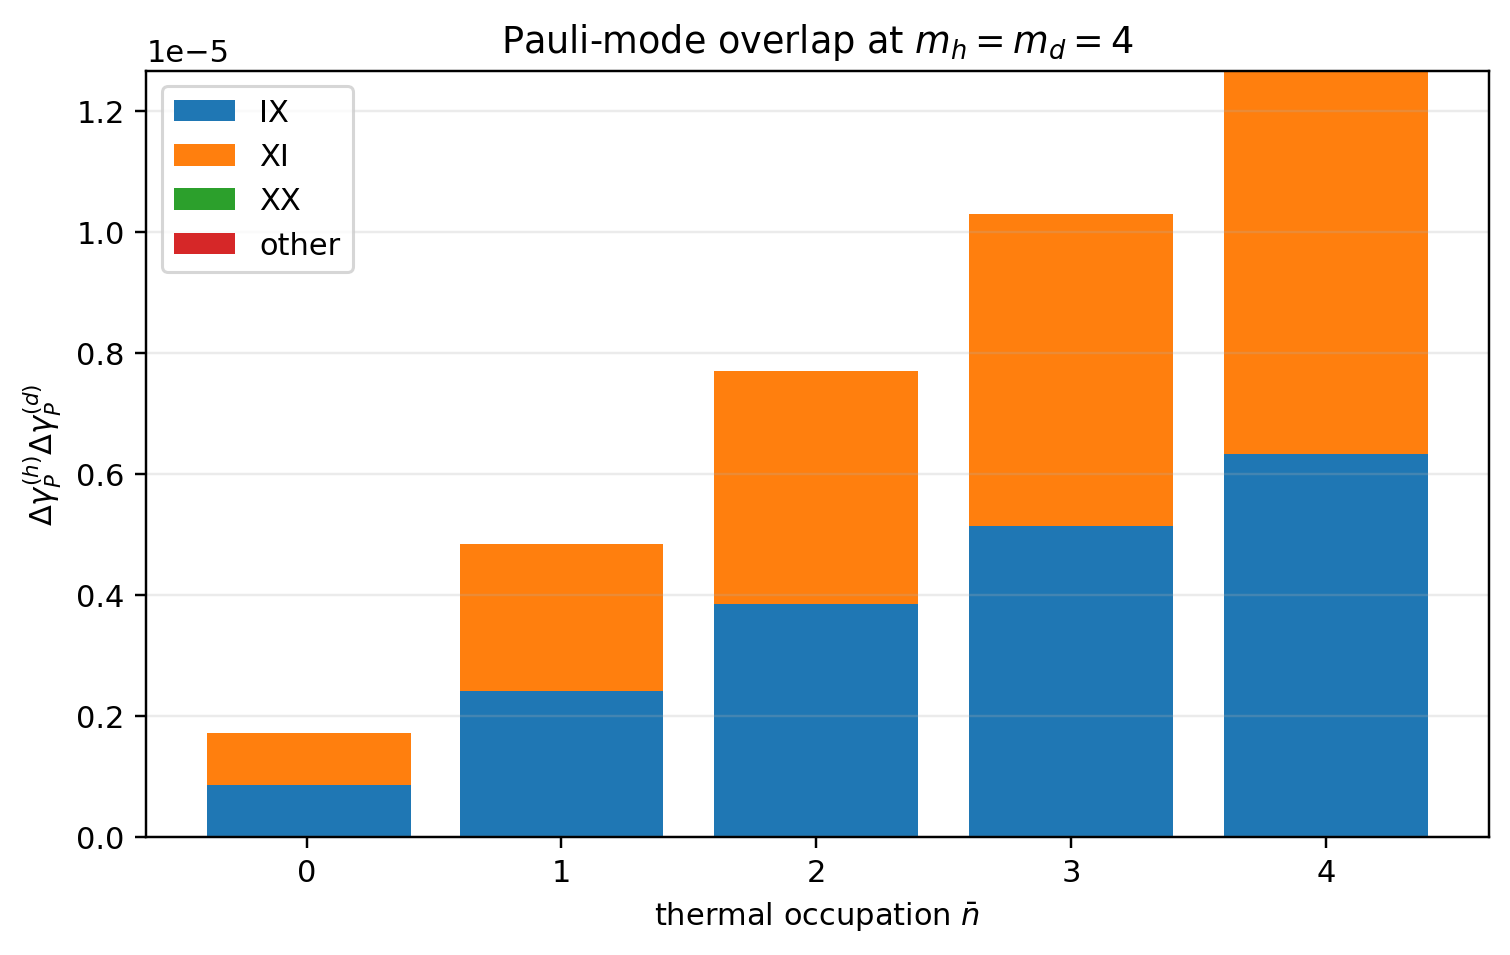

In [29]:
mode_endpoint = hd_models['model2_contributions'][
    np.isclose(hd_models['model2_contributions']['nbar'], 4.0)
    & np.isclose(
        hd_models['model2_contributions']['multiplier_heating'], 4.0
    )
    & np.isclose(
        hd_models['model2_contributions'][
            'multiplier_motional_dephasing'
        ], 4.0
    )
].sort_values('gamma_mode_product', ascending=False)
display(mode_endpoint[[
    'pauli', 'delta_gamma_heating',
    'delta_gamma_motional_dephasing', 'gamma_mode_product',
    'gamma_overlap_fraction',
]].head(8))
display(hd_models['model2_scales'])
display(Image(filename=str(hd_models['paths']['mode_figure'])))


### 6.3 Model 3：共通の運動モードを介する熱依存

Model 1で得た $\kappa(\bar n)$ を、2パラメータの直線

$$C_{hd}^{\mathrm{extra}}=-(\alpha+\beta\bar n)m_hm_d$$

に縮約する。heatingは運動量子数を変え、motional dephasingは同じ運動の位相を乱す。どちらもスピンと結合した共通の運動自由度に作用するため、両者の組合せ効果が $m_hm_d$ に比例し、熱占有数とともに強くなる、という最小の物理モデルである。


,alpha_zero_point,beta_per_nbar,formula
0,1.113927e-07,3.349859e-07,-(alpha + beta*nbar)*m_heating*m_motional_deph...


,model,count,rmse,nrmse_to_max_abs_extra,r_squared
0,per_nbar_rate_product,80,5.134921e-08,0.002299,0.999835
6,global_pauli_gamma_overlap,80,3.282115e-07,0.014696,0.993253
12,shared_motion_linear_nbar,80,2.274672e-07,0.010185,0.996759


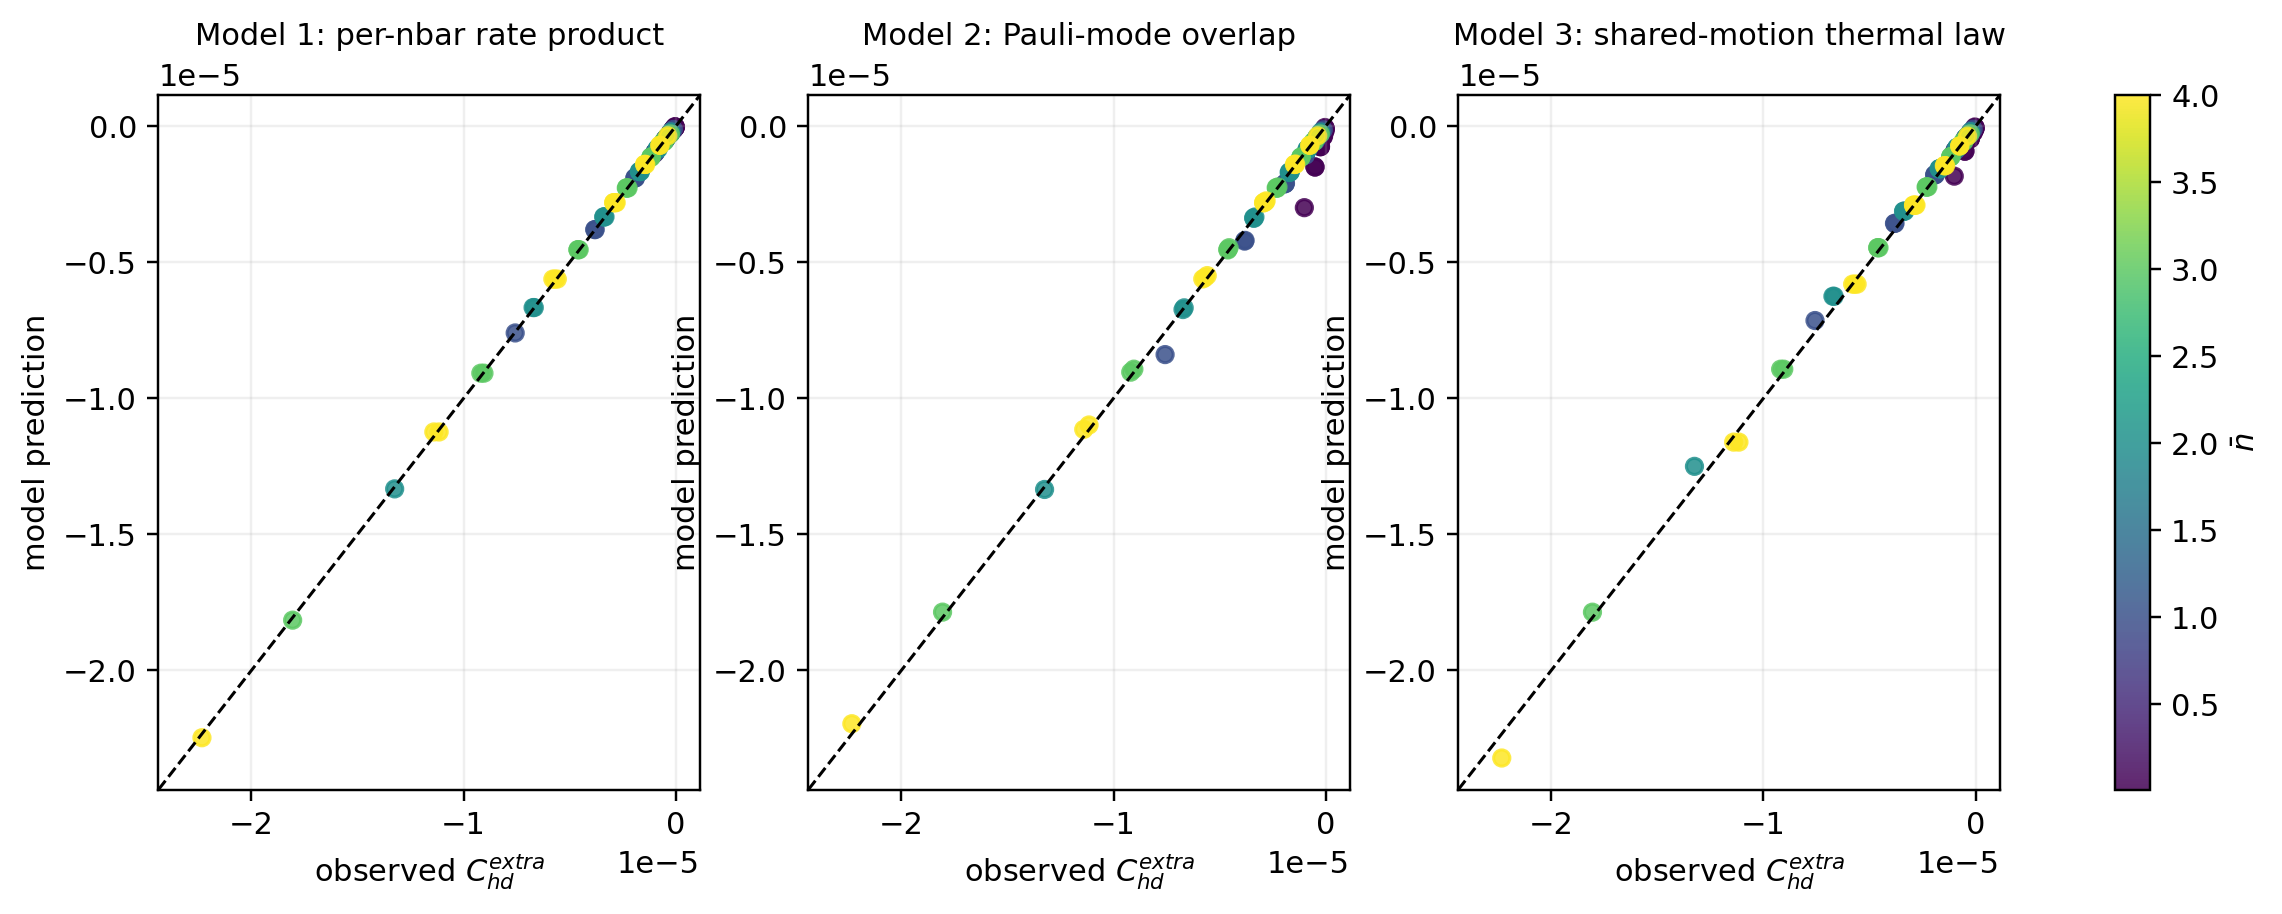

In [30]:
display(hd_models['model3_fit'])
overall_metrics = hd_models['metrics'][
    hd_models['metrics']['scope'].eq('all')
][[
    'model', 'count', 'rmse', 'nrmse_to_max_abs_extra', 'r_squared'
]]
display(overall_metrics)
display(Image(filename=str(hd_models['paths']['comparison_figure'])))


### 6.4 この節から言えることと限界

- Model 1は各 $\bar n$ のgridを最も良く記述する。これにより、追加補正がほぼ $m_hm_d$ に比例することを確認できる。
- Model 2は、追加補正の $\bar n$ 依存が、2つのノイズが共通に強めるlocalな $IX$ と $XI$ 散逸モードの重なりと強く対応することを示す。
- Model 3は、その変化を「共通の運動モードを介し、熱占有数とともに強くなる」と2パラメータで表す。論文本文の物理的な要約に向く。
- ただし、これらは現在のチャネルに見える非加法性の説明であり、heating浴とdephasing浴の統計的相関を証明したものではない。またnominal倍率付近の $C_{hd}^{\mathrm{extra}}$ は数値誤差の大きさに近く、強い根拠は高い $\bar n$ とノイズ倍率の領域にある。


## 7. Effective interaction generatorのモード別可視化

Section 5で保存したcomponent-resolved interactionから、heating×motional dephasingの追加成分を

$$
K_{\rm int} \simeq m_hm_d\left[a_X(\bar n)(\mathcal D_{IX}+\mathcal D_{XI})-a_{XX}(\bar n)\mathcal D_{XX}+b_{XX}(\bar n)\mathcal H_{XX}\right]
$$

として整理する。各 $\bar n$ で原点を通る $m_hm_d$ 比例フィットを行い、$a_X$、$a_{XX}$、$b_{XX}$ を求める。$a_X$ は $IX$ と $XI$ の平均であり、両者の差も対称性の確認用にCSVへ保存する。この節は保存済みCSVだけを使うため、MEやQPTは再実行しない。


In [36]:
import importlib
import heating_dephasing_models as hdm

PAIRWISE_GENERATOR_INTERACTION_PATH = (
    OUTPUT_DIR
    / 'top3_pairwise_generator'
    / 'pairwise_generator_interactions.csv'
)
MODE_RESOLVED_OUTPUT_DIR = (
    OUTPUT_DIR
    / 'top3_pairwise_generator'
    / 'mode_resolved_model'
)
SELECTED_MODE_RESOLVED_NBAR = 4.0

# Trueにしたときだけ、保存済みSection 5のCSVから係数と図を生成する。
# ME/QPTの時間発展は実行しない。
EXECUTE_MODE_RESOLVED_PLOTS = True
mode_resolved_result = None

if EXECUTE_MODE_RESOLVED_PLOTS:
    hdm = importlib.reload(hdm)
    mode_resolved_result = hdm.run_mode_resolved_interaction_model(
        pairwise_generator_interactions_path=(
            PAIRWISE_GENERATOR_INTERACTION_PATH
        ),
        output_dir=MODE_RESOLVED_OUTPUT_DIR,
        selected_nbar=SELECTED_MODE_RESOLVED_NBAR,
    )
    display(mode_resolved_result['coefficients'])
else:
    print(
        'Code is ready. Set EXECUTE_MODE_RESOLVED_PLOTS=True '
        'to fit the saved Section 5 data and create the figures.'
    )


,nbar,a_X_per_gate,a_X_rmse,a_X_max_abs_residual,a_X_nrmse_to_max_abs_response,a_X_r_squared,a_XX_per_gate,a_XX_rmse,a_XX_max_abs_residual,a_XX_nrmse_to_max_abs_response,a_XX_r_squared,b_XX_rad_per_gate,b_XX_rad_rmse,b_XX_rad_max_abs_residual,b_XX_rad_nrmse_to_max_abs_response,b_XX_rad_r_squared
0,0.01,1.178094e-07,5.044794e-09,1.149547e-08,0.002683,0.999884,8.672038e-09,1.276143e-08,2.734877e-08,0.090709,0.889455,1.180801e-07,1.094087e-08,2.324391e-08,0.005776,0.999467
1,1.00,1.484442e-07,8.103796e-09,1.616847e-08,0.003433,0.999810,3.673896e-08,8.721262e-09,2.229931e-08,0.015122,0.996390,1.026598e-07,1.053443e-08,3.139787e-08,0.006470,0.999329
2,2.00,1.987158e-07,1.511777e-08,3.174234e-08,0.004792,0.999630,8.026120e-08,1.320356e-08,2.892342e-08,0.010427,0.998251,8.569558e-08,2.602285e-08,6.812381e-08,0.019230,0.993956
3,3.00,2.658112e-07,2.417623e-08,4.462047e-08,0.005744,0.999467,1.277748e-07,3.433233e-08,7.171002e-08,0.016795,0.995693,5.889044e-08,4.862769e-08,7.808963e-08,0.048056,0.965775
4,4.00,3.419237e-07,3.132652e-08,6.261155e-08,0.005785,0.999462,1.958732e-07,3.407352e-08,6.134115e-08,0.011011,0.998044,5.423426e-08,3.102232e-08,5.692108e-08,0.036878,0.977341


### 7.1 出力する図と数値

- `mode_coefficients_vs_nbar.png`: $a_X(\bar n)$、$a_{XX}(\bar n)$、$b_{XX}(\bar n)$ の温度依存
- `mode_rate_scaling_nbar_4.png`: $m_h=m_d=m$ に沿った生のinteraction成分と $m^2$ モデルの比較
- `mode_model_heatmaps_nbar_4.png`: $(m_h,m_d)$ grid上の観測値・モデル・残差
- `mode_resolved_coefficients_by_nbar.csv`: 係数、RMSE、最大残差、$R^2$
- `mode_resolved_bilinear_grid.csv`: 各grid点の生値、予測値、残差、$IX-XI$ 非対称成分

> 符号の注意：$-a_{XX}\mathcal D_{XX}$ は「2ノイズを同時に入れたときの $\gamma_{XX}$ の追加補正」を表す。全体の $\gamma_{XX}$ が負である、または散逸率自体が負であるという意味ではない。


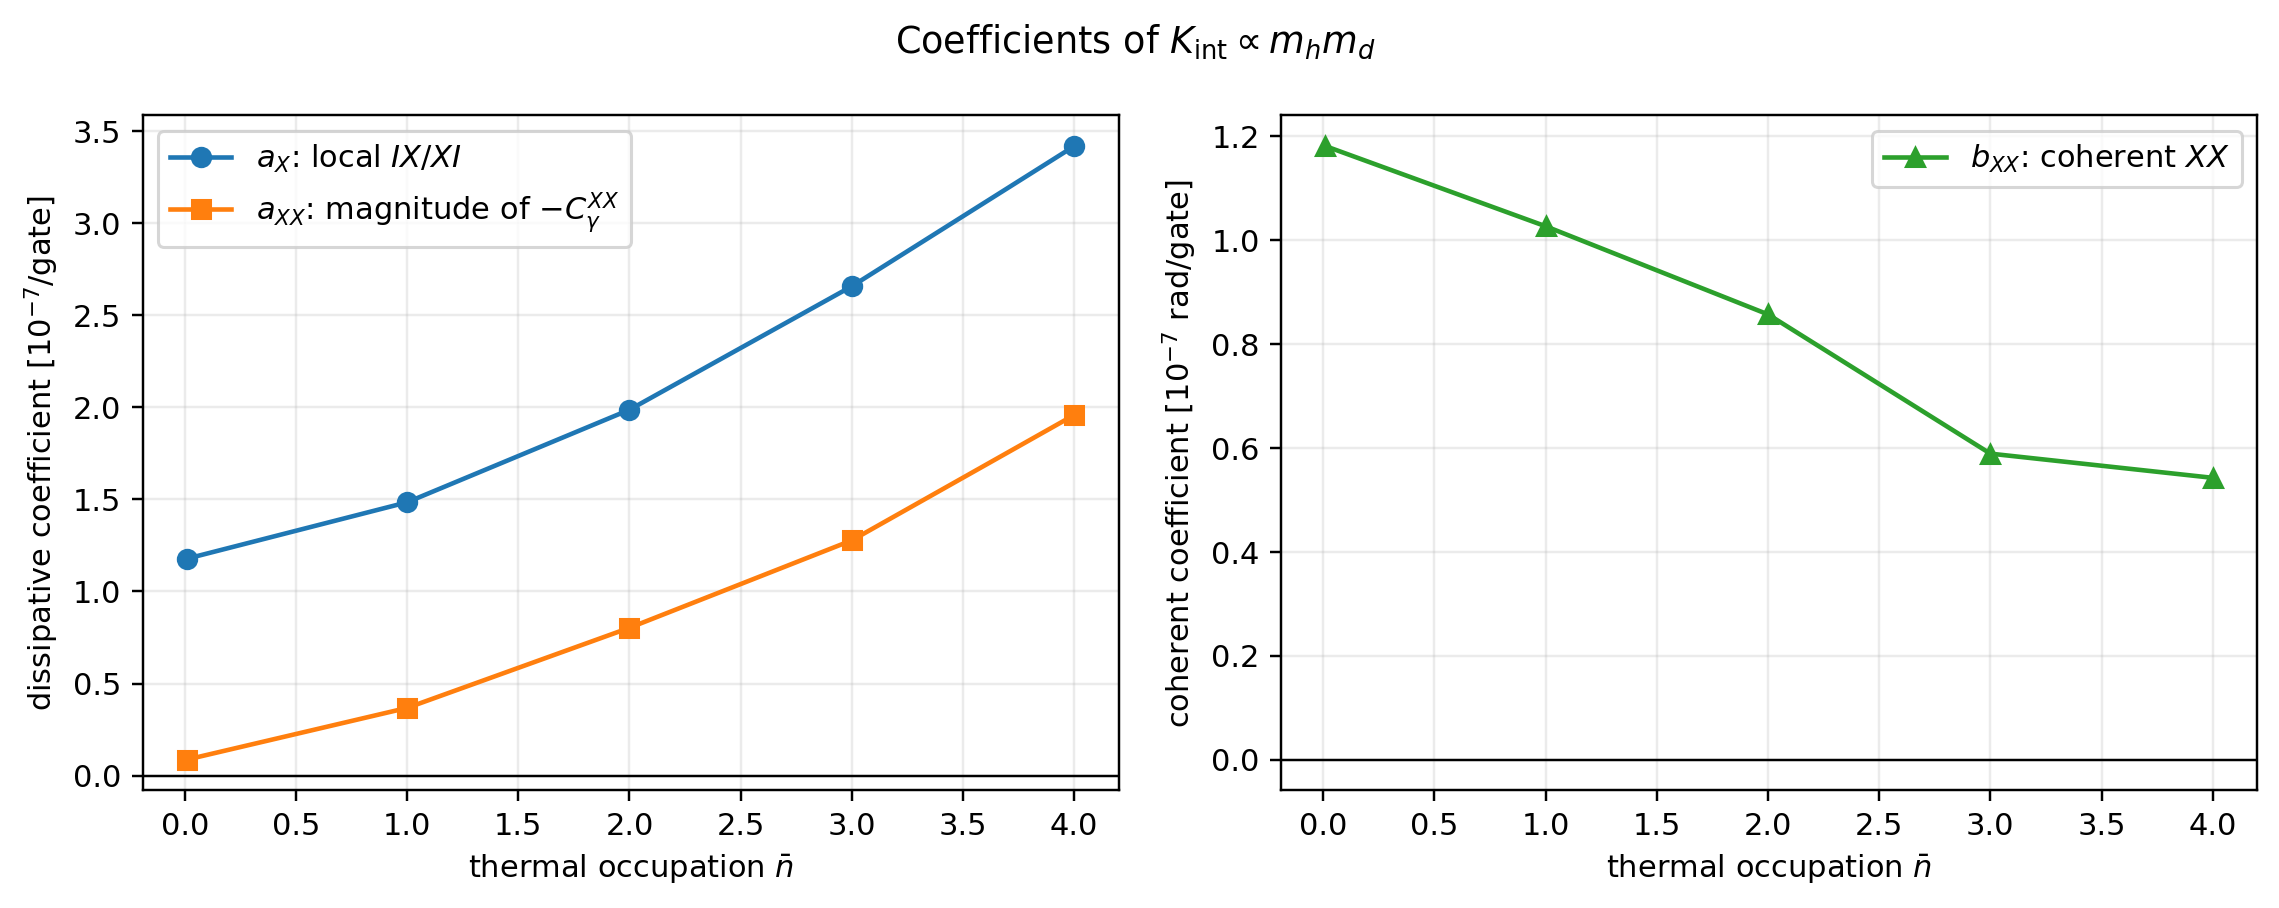

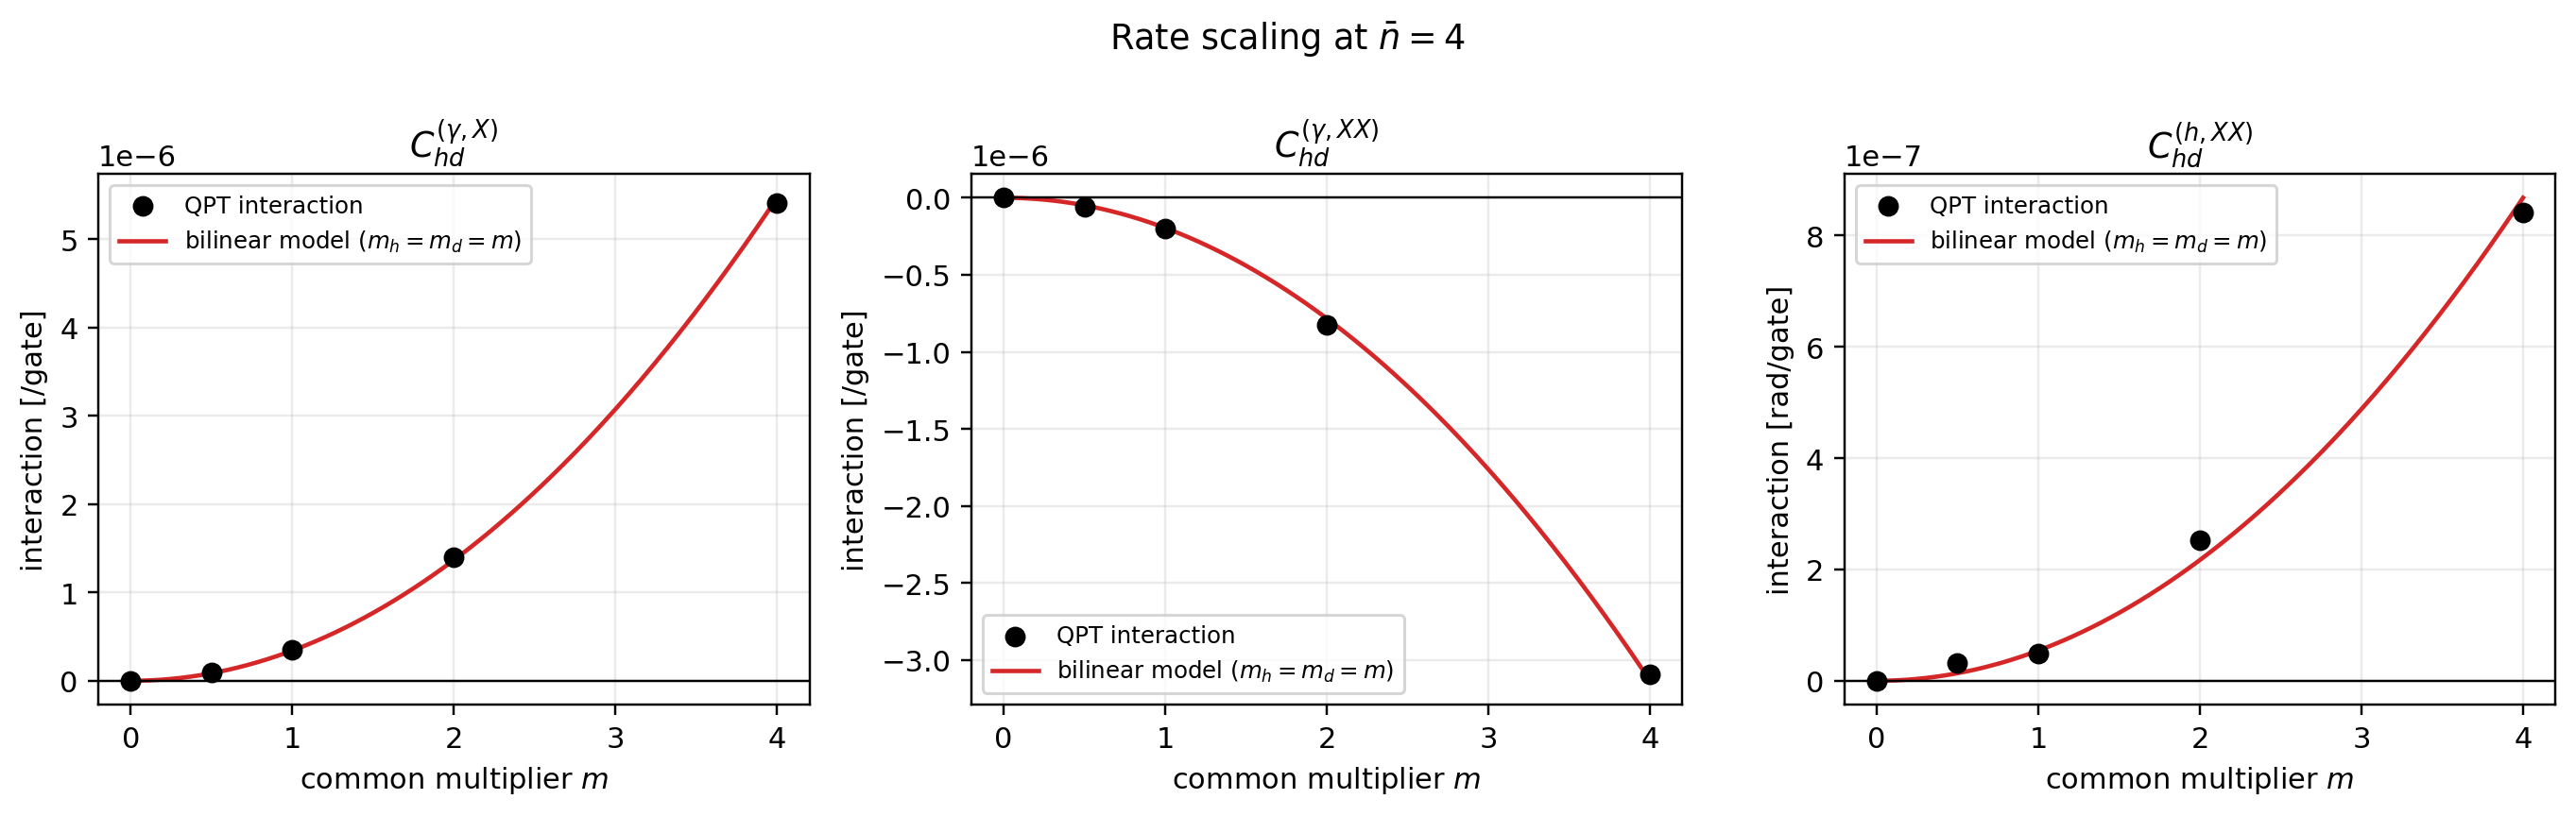

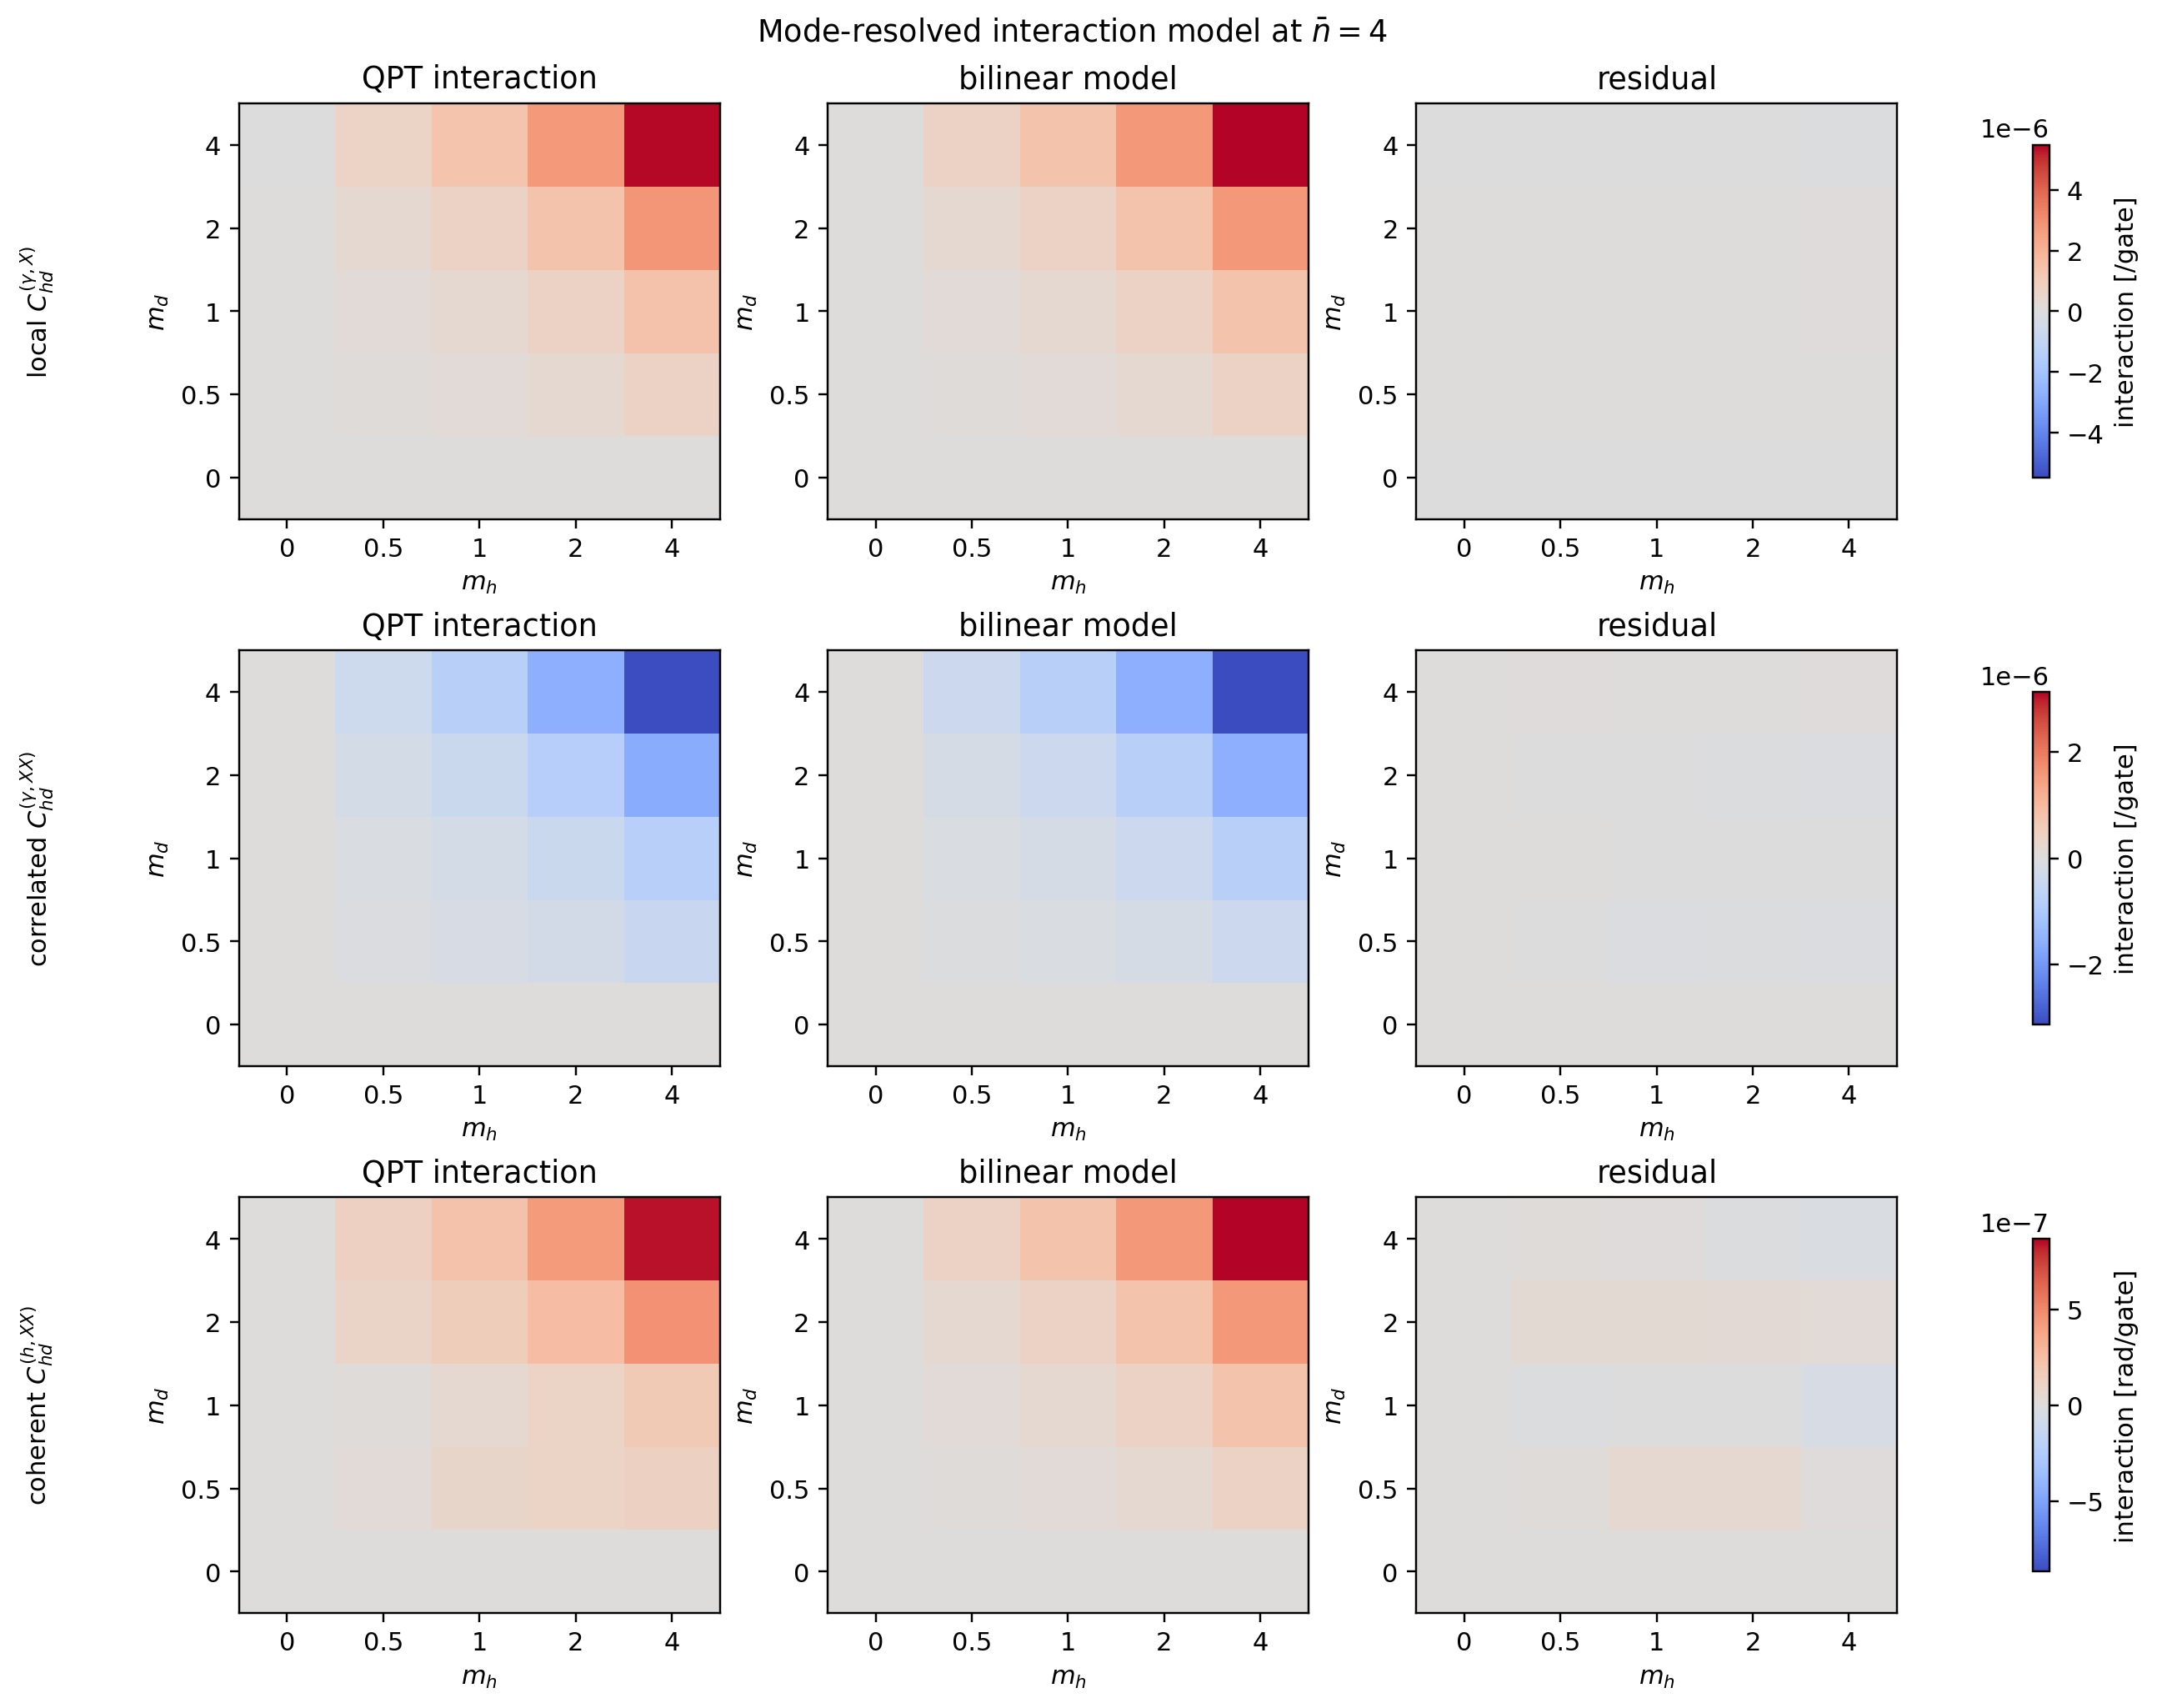

In [37]:
if mode_resolved_result is not None:
    for figure_key in [
        'coefficient_figure',
        'rate_scaling_figure',
        'heatmap_figure',
    ]:
        display(Image(filename=str(mode_resolved_result['paths'][figure_key])))


### 7.2 双線形モデルの残差と採用判定

各成分の観測値を $C_k$、双線形モデルの予測値を $\hat C_k=A m_{h,k}m_{d,k}$ とし、残差 $r_k=C_k-\hat C_k$ を計算する。ゼロに近い点で発散する点ごとの相対誤差は主尺度にせず、以下の2つを使う。

$$
E_2=\frac{\lVert\bm r\rVert_2}{\lVert\bm C\rVert_2},\qquad
E_\infty=\frac{\max_k|r_k|}{\max_k|C_k|}.
$$

$E_2$ はgrid全体の誤差、$E_\infty$ は最も悪いgrid点の誤差を表す。さらに、1点ずつ外して係数を再推定するleave-one-out cross-validation（LOOCV）を行い、特定の1点だけで係数が決まっていないか確認する。

本ノートでは、決定論的な数値データに対するモデル縮約の運用基準として次を提案する。

- **strongly supported**: fitとLOOCVの両方で $E_2\leq5\%$ かつ $E_\infty\leq10\%$
- **acceptable approximation**: 両方で $E_2\leq10\%$ かつ $E_\infty\leq20\%$
- **insufficient**: 上記を満たさず、高次の $m_h^2m_d$、$m_hm_d^2$ 等を検討すべき

$E_2=5\%$ は、残差の二乗ノルムが信号の $0.25\%$ 以下（$E_2^2\leq0.0025$）、$E_2=10\%$ は $1\%$ 以下に対応する。$E_\infty$ も併用することで、全体平均は良いが一部のgrid点で大きく外れるモデルを除外する。$R^2$ も出力するが、原点固定fitと大きなdynamic rangeの影響を受けるため、採用判定には使わない。

> これらは統計的な信頼区間ではない。数値誤差を含めた物理的な精度を主張するには、MEのHilbert空間打ち切り、時間刻み、CPTP射影量、generator分解残差に対する収束確認が別途必要である。


In [39]:
import importlib
import heating_dephasing_models as hdm
hdm = importlib.reload(hdm)

RESIDUAL_THRESHOLDS = {
    'strong_relative_l2': 0.05,
    'strong_normalized_max': 0.10,
    'acceptable_relative_l2': 0.10,
    'acceptable_normalized_max': 0.20,
}

mode_resolved_residual_points = None
mode_resolved_residual_summary = None

if mode_resolved_result is None:
    print(
        'Run the Section 7 configuration cell with '
        'EXECUTE_MODE_RESOLVED_PLOTS=True first.'
    )
else:
    (
        mode_resolved_residual_points,
        mode_resolved_residual_summary,
    ) = hdm.evaluate_mode_resolved_bilinear_residuals(
        mode_resolved_result['grid'],
        **RESIDUAL_THRESHOLDS,
    )

    residual_points_path = (
        MODE_RESOLVED_OUTPUT_DIR / 'mode_resolved_residual_points.csv'
    )
    residual_summary_path = (
        MODE_RESOLVED_OUTPUT_DIR / 'mode_resolved_residual_summary.csv'
    )
    mode_resolved_residual_points.to_csv(
        residual_points_path, index=False
    )
    mode_resolved_residual_summary.to_csv(
        residual_summary_path, index=False
    )

    residual_columns = [
        'nbar', 'component', 'n_active_points',
        'fit_relative_l2_error',
        'fit_normalized_max_abs_error',
        'loocv_relative_l2_error',
        'loocv_normalized_max_abs_error',
        'fit_r_squared', 'assessment',
    ]
    display(mode_resolved_residual_summary[residual_columns])

    assessment_rank = {
        'strongly_supported': 0,
        'acceptable_approximation': 1,
        'insufficient': 2,
    }
    worst_index = (
        mode_resolved_residual_summary['assessment']
        .map(assessment_rank)
        .idxmax()
    )
    worst = mode_resolved_residual_summary.loc[worst_index]
    print(
        'Overall decision (worst component/nbar): '
        f"{worst['assessment']} -- {worst['component']}, "
        f"nbar={worst['nbar']:g}"
    )
    print(f'Saved: {residual_points_path}')
    print(f'Saved: {residual_summary_path}')


,nbar,component,n_active_points,fit_relative_l2_error,fit_normalized_max_abs_error,loocv_relative_l2_error,loocv_normalized_max_abs_error,fit_r_squared,assessment
0,0.01,coherent_h_XX,16,0.017439,0.012271,0.018057,0.012381,0.999467,strongly_supported
1,0.01,correlated_gamma_XX,16,0.266948,0.194397,0.272714,0.196134,0.889455,insufficient
2,0.01,local_gamma_X,16,0.008060,0.006115,0.009210,0.006339,0.999884,strongly_supported
3,1.00,coherent_h_XX,16,0.019312,0.019284,0.023978,0.020402,0.999329,strongly_supported
4,1.00,correlated_gamma_XX,16,0.044640,0.038664,0.054732,0.044379,0.996390,acceptable_approximation
5,1.00,local_gamma_X,16,0.010276,0.006850,0.014492,0.014325,0.999810,strongly_supported
6,2.00,coherent_h_XX,16,0.057068,0.050341,0.061387,0.050453,0.993956,acceptable_approximation
7,2.00,correlated_gamma_XX,16,0.030951,0.022841,0.039488,0.032583,0.998251,strongly_supported
8,2.00,local_gamma_X,16,0.014319,0.010062,0.019506,0.018222,0.999630,strongly_supported
9,3.00,coherent_h_XX,16,0.153588,0.077171,0.193260,0.158947,0.965775,insufficient


Overall decision (worst component/nbar): insufficient -- correlated_gamma_XX, nbar=0.01
Saved: results/error_generator_rate_nbar/top3_pairwise_generator/mode_resolved_model/mode_resolved_residual_points.csv
Saved: results/error_generator_rate_nbar/top3_pairwise_generator/mode_resolved_model/mode_resolved_residual_summary.csv
